# Career Atlas: Modeling, Clustering, BEA RPP, and Dashboard Outputs

This notebook reads the cleaned 2020-2024 occupation–metro dataset created by the data-wrangling notebook with BEA Regional Price Parities.

Main outputs:

- RPP-aware occupation-specific career-city scores for dashboard ranking
- Metro clustering with K-Means and PCA using wage, rent, RPP, and occupational mix features
- Nearest-neighbor metro similarity tables
- Forecasting models using time-based train/validation/test splits
- Next-year predictions for rent burden and RPP-adjusted income after rent
- Dashboard-ready combined output tables

This notebook assumes the following file already exists:

- `data/processed/career_city_fit_2020_2024.csv`

This notebook starts from the cleaned occupation-metro-year dataset created in the data-wrangling notebook. The goal here is to turn the processed data into dashboard-ready outputs and predictive signals.

The notebook has four main jobs:

1. Build a transparent latest-year dashboard ranking score.
2. Cluster metros based on affordability, price levels, wages, and occupational mix.
3. Create nearest-neighbor metro recommendations.
4. Train supervised models to predict next-year affordability outcomes.

The goal is to create useful short-term forecasts and interpretable dashboard features that help users compare career-city options.

## 1. Setup

In [11]:
%pip install -q polars pandas numpy matplotlib scikit-learn joblib pyarrow duckdb


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from IPython.display import display

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(18)
pl.Config.set_fmt_str_lengths(90)

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELING_DIR = DATA_DIR / "modeling"
MODEL_DIR = MODELING_DIR / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "modeling"

for path in [MODELING_DIR, MODEL_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FINAL_DATASET_CSV_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.csv"

LATEST_SCORE_CSV_PATH = PROCESSED_DIR / "career_city_scores_latest.csv"
METRO_PROFILE_CSV_PATH = MODELING_DIR / "metro_profiles_clustered_latest.csv"
NEAREST_METROS_CSV_PATH = MODELING_DIR / "nearest_metros_latest.csv"

REGRESSION_METRICS_ALL_TARGETS_CSV_PATH = MODELING_DIR / "regression_model_metrics_all_targets.csv"
FUTURE_PREDICTIONS_CSV_PATH = PROCESSED_DIR / "career_city_next_year_predictions_latest.csv"
FINAL_DASHBOARD_OUTPUT_CSV_PATH = PROCESSED_DIR / "dashboard_modeling_output_latest.csv"

## 2. Helper Functions

In [13]:
def print_shape(label: str, df) -> None:
    if isinstance(df, pl.DataFrame):
        print(f"{label}: {df.height:,} rows × {df.width:,} columns")
    else:
        print(f"{label}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


def read_final_dataset(path: Path = FINAL_DATASET_CSV_PATH) -> pl.DataFrame:
    df = pl.read_csv(path, infer_schema_length=5000)

    if "cbsa_code" in df.columns:
        df = df.with_columns(
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code")
        )

    if "occ_code" in df.columns:
        df = df.with_columns(
            pl.col("occ_code").cast(pl.Utf8).alias("occ_code")
        )

    if "year" in df.columns:
        df = df.with_columns(pl.col("year").cast(pl.Int64).alias("year"))

    return df


def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.replace(0, np.nan)


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": r2_score(y_true, y_pred),
    }


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def get_pipeline_feature_names(
    pipeline: Pipeline,
    numeric_features: list[str],
    categorical_features: list[str],
) -> list[str]:
    preprocessor = pipeline.named_steps["preprocess"]
    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_features)

    if "cat" in preprocessor.named_transformers_:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        feature_names.extend(list(encoder.get_feature_names_out(categorical_features)))

    return feature_names


def save_json(obj: dict, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def percentile_rank_within_group(
    df: pd.DataFrame,
    group_col: str,
    value_col: str,
    higher_is_better: bool = True,
) -> pd.Series:
    return (
        df
        .groupby(group_col)[value_col]
        .rank(method="average", pct=True, ascending=higher_is_better)
    )

## 3. Load Processed Dataset

In [14]:
df_all = read_final_dataset()

print_shape("Loaded final processed dataset", df_all)

latest_year = df_all.select(pl.col("year").max()).item()
earliest_year = df_all.select(pl.col("year").min()).item()

print(f"Years available: {earliest_year}-{latest_year}")

display(df_all.head(10).to_pandas())

Loaded final processed dataset: 689,932 rows × 57 columns
Years available: 2020-2024


,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,...,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,has_valid_rpp,has_valid_real_wage,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-1021,General and Operations Managers,detailed,1320.0,...,7.185387,False,False,True,True,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2022,Sales Managers,detailed,90.0,...,4.499810,True,False,True,True,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,...,3.688879,True,False,True,True,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,...,4.941642,False,False,True,True,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,...,4.248495,True,False,True,True,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3031,Financial Managers,detailed,120.0,...,4.787492,False,False,True,True,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3051,Industrial Production Managers,detailed,50.0,...,3.912023,True,False,True,True,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3121,Human Resources Managers,detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-9021,Construction Managers,detailed,160.0,...,5.075174,False,False,True,True,True,True,"Abilene, TX",0.141598,0.170597


In [15]:
year_summary = (
    df_all
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),

        (pl.col("rent_to_median_wage_ratio").is_not_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_valid_rent_burden"),

        (pl.col("rpp_all_items").is_not_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_valid_bea_rpp"),

        (pl.col("real_income_after_rent_median").is_not_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_valid_real_income_after_rent"),
    ])
    .sort("year")
)

display(year_summary.to_pandas())

,year,n_rows,n_metros,n_occupations,pct_valid_rent_burden,pct_valid_bea_rpp,pct_valid_real_income_after_rent
0,2020,131010,396,785,91.26,90.88,88.51
1,2021,138116,396,826,92.24,90.87,89.36
2,2022,139124,396,828,92.45,90.93,89.55
3,2023,140518,396,826,91.29,90.89,89.45
4,2024,141164,393,823,98.33,99.03,97.38


## 4. Dashboard Ranking Score

The Career Atlas dashboard score is not meant to be a predictive model, but a transparent ranking score that summarizes the several career-city dimensions into one default score from 0 to 100, where higher is better. 

The score ranks metros **within each occupation**, which is important because software developers should be compared with other software-developer metro outcomes, nurses with other nurse outcomes, and so on.

The score combines:

- RPP-adjusted income after rent,
- rent affordability,
- RPP-adjusted wage,
- occupational concentration,
- employment scale.

This design reflects the idea that a good career-city fit should not be based on only one factor. A metro with high wages but very high rent may not be ideal. A metro with low rent but almost no local employment in the occupation may also not be ideal. The score balances these tradeoffs.

In [16]:
latest = df_all.filter(pl.col("year") == latest_year).to_pandas()

score_required_cols = [
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "bea_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "wage_annual_median",
    "real_wage_annual_median",
    "annual_rent",
    "rpp_all_items",
    "rpp_services_housing",
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "cost_adjusted_rent_burden_median",
    "real_income_after_rent_median",
    "tot_emp",
    "jobs_1000",
    "loc_quotient",
]

score_df = latest[[c for c in score_required_cols if c in latest.columns]].copy()

required_score_nonnull = [
    "occ_code",
    "occ_title",
    "cbsa_code",
    "bls_msa_name",
    "wage_annual_median",
    "real_wage_annual_median",
    "annual_rent",
    "rpp_all_items",
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "real_income_after_rent_median",
]

score_df = score_df.dropna(
    subset=[c for c in required_score_nonnull if c in score_df.columns]
)

score_df["tot_emp"] = score_df["tot_emp"].fillna(0)
score_df["loc_quotient"] = score_df["loc_quotient"].fillna(0)
score_df["jobs_1000"] = score_df["jobs_1000"].fillna(0)
score_df["log_tot_emp_for_score"] = np.log1p(score_df["tot_emp"].clip(lower=0))

score_df["real_income_after_rent_component"] = percentile_rank_within_group(
    score_df,
    "occ_code",
    "real_income_after_rent_median",
    higher_is_better=True,
)

score_df["rent_affordability_component"] = percentile_rank_within_group(
    score_df,
    "occ_code",
    "median_wage_to_rent_ratio",
    higher_is_better=True,
)

score_df["real_wage_component"] = percentile_rank_within_group(
    score_df,
    "occ_code",
    "real_wage_annual_median",
    higher_is_better=True,
)

score_df["lq_component"] = percentile_rank_within_group(
    score_df,
    "occ_code",
    "loc_quotient",
    higher_is_better=True,
)

score_df["employment_component"] = percentile_rank_within_group(
    score_df,
    "occ_code",
    "log_tot_emp_for_score",
    higher_is_better=True,
)

# Supplementary component, not currently included in the main score.
# Because lower cost-adjusted burden is better, ascending=False gives lower values higher percentiles.
if "cost_adjusted_rent_burden_median" in score_df.columns:
    score_df["cost_adjusted_burden_component"] = percentile_rank_within_group(
        score_df,
        "occ_code",
        "cost_adjusted_rent_burden_median",
        higher_is_better=False,
    )

score_df["career_city_score"] = (
    0.35 * score_df["real_income_after_rent_component"]
    + 0.25 * score_df["rent_affordability_component"]
    + 0.15 * score_df["real_wage_component"]
    + 0.15 * score_df["lq_component"]
    + 0.10 * score_df["employment_component"]
)

score_df["career_city_score_0_100"] = 100 * score_df["career_city_score"]

score_df["low_employment_warning"] = score_df["tot_emp"] < 100
score_df["low_lq_warning"] = score_df["loc_quotient"] < 0.75
score_df["high_cost_warning"] = score_df["rpp_all_items"] > 110

score_df = score_df.sort_values(
    ["occ_title", "career_city_score_0_100"],
    ascending=[True, False],
)

score_df.to_csv(LATEST_SCORE_CSV_PATH, index=False)

print_shape("Latest-year RPP-aware dashboard score table", score_df)
print(f"Saved: {LATEST_SCORE_CSV_PATH}")

display(score_df.head(15))

Latest-year RPP-aware dashboard score table: 137,464 rows × 32 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/career_city_scores_latest.csv


,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,wage_annual_median,real_wage_annual_median,...,rent_affordability_component,real_wage_component,lq_component,employment_component,cost_adjusted_burden_component,career_city_score,career_city_score_0_100,low_employment_warning,low_lq_warning,high_cost_warning
122770,2024,44100,"Springfield, IL","Springfield, IL Metro Area","Springfield, IL (Metropolitan Statistical Area)",IL,13-2011,Accountants and Auditors,83970.0,90538.573508,...,0.989664,0.976744,0.993540,0.700258,0.974160,0.960271,96.027132,False,False,False
95144,2024,37620,"Parkersburg-Vienna, WV","Parkersburg-Vienna, WV Metro Area","Parkersburg-Vienna, WV (Metropolitan Statistic...",WV,13-2011,Accountants and Auditors,95640.0,109847.701744,...,1.000000,0.997416,1.000000,0.418605,1.000000,0.941473,94.147287,False,False,False
120860,2024,43620,"Sioux Falls, SD-MN","Sioux Falls, SD-MN Metro Area","Sioux Falls, SD-MN (Metropolitan Statistical A...",SD,13-2011,Accountants and Auditors,79650.0,87883.836656,...,0.917313,0.940568,0.978036,0.770026,0.894057,0.937791,93.779070,False,False,False
80658,2024,33220,"Midland, MI","Midland, MI Metro Area","Midland, MI (Metropolitan Statistical Area)",MI,13-2011,Accountants and Auditors,86390.0,93982.876601,...,0.984496,0.992248,0.987080,0.359173,0.976744,0.928036,92.803618,False,False,False
33198,2024,19340,"Davenport-Moline-Rock Island, IA-IL","Davenport-Moline-Rock Island, IA-IL Metro Area","Davenport-Moline-Rock Island, IA-IL (Metropoli...",IA,13-2011,Accountants and Auditors,77280.0,86754.453912,...,0.966408,0.927649,0.755814,0.702842,0.971576,0.905362,90.536176,False,False,False
129310,2024,46140,"Tulsa, OK","Tulsa, OK Metro Area","Tulsa, OK (Metropolitan Statistical Area)",OK,13-2011,Accountants and Auditors,78500.0,87990.674109,...,0.780362,0.948320,0.877261,0.865633,0.806202,0.892829,89.282946,False,False,False
136888,2024,48620,"Wichita, KS","Wichita, KS Metro Area","Wichita, KS (Metropolitan Statistical Area)",KS,13-2011,Accountants and Auditors,74890.0,84197.153329,...,0.883721,0.839793,0.830749,0.821705,0.888889,0.868411,86.841085,False,False,False
18941,2024,15380,"Buffalo-Cheektowaga, NY","Buffalo-Cheektowaga, NY Metro Area","Buffalo-Cheektowaga, NY (Metropolitan Statisti...",NY,13-2011,Accountants and Auditors,80240.0,83719.377321,...,0.888889,0.813953,0.822997,0.878553,0.736434,0.860401,86.040052,False,False,False
3881,2024,11180,"Ames, IA","Ames, IA Metro Area","Ames, IA (Metropolitan Statistical Area)",IA,13-2011,Accountants and Auditors,76250.0,85838.117753,...,0.901809,0.901809,0.838501,0.390181,0.891473,0.857429,85.742894,False,False,False
27094,2024,17410,"Cleveland, OH","Cleveland, OH Metro Area","Cleveland, OH (Metropolitan Statistical Area)",OH,13-2011,Accountants and Auditors,78360.0,83430.043759,...,0.829457,0.775194,0.918605,0.935401,0.741602,0.852519,85.251938,False,False,False


In [17]:
example_occupation = None

for keyword in ["software developers", "registered nurses", "accountants", "data scientists"]:
    matches = score_df.loc[
        score_df["occ_title"].str.lower().str.contains(keyword, na=False),
        "occ_title",
    ].unique()

    if len(matches) > 0:
        example_occupation = matches[0]
        break

if example_occupation is None:
    example_occupation = score_df["occ_title"].value_counts().index[0]

print(f"Example occupation: {example_occupation}")

example_score_table = (
    score_df
    .loc[score_df["occ_title"] == example_occupation]
    .sort_values("career_city_score_0_100", ascending=False)
    .head(15)
    [
        [
            "bls_msa_name",
            "career_city_score_0_100",
            "wage_annual_median",
            "real_wage_annual_median",
            "annual_rent",
            "rpp_all_items",
            "real_income_after_rent_median",
            "rent_to_median_wage_ratio",
            "tot_emp",
            "loc_quotient",
            "low_employment_warning",
            "high_cost_warning",
        ]
    ]
)

display(example_score_table)

Example occupation: Software Developers


,bls_msa_name,career_city_score_0_100,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,real_income_after_rent_median,rent_to_median_wage_ratio,tot_emp,loc_quotient,low_employment_warning,high_cost_warning
13453,"Binghamton, NY",94.523810,129600.0,139560.427727,11268,92.863,127426.423872,0.086944,1130.0,1.10,False,False
3894,"Ames, IA",91.316138,127040.0,143014.747270,12000,88.830,129505.797591,0.094458,440.0,0.73,False,False
18965,"Buffalo-Cheektowaga, NY",91.183862,128780.0,134364.175118,12684,95.844,121130.169859,0.098494,3720.0,0.65,False,False
35657,"Des Moines-West Des Moines, IA",90.251323,124630.0,135909.095866,13800,91.701,120860.186912,0.110728,4750.0,1.09,False,False
14867,"Bloomington, IL",89.179894,121590.0,129991.340325,12108,93.537,117046.730171,0.099581,1300.0,1.35,False,False
138722,"Winston-Salem, NC",88.544974,125140.0,135958.193453,12192,92.043,122712.210597,0.097427,1270.0,0.43,False,False
106419,"Rochester, MN",87.949735,130480.0,143667.213530,15312,90.821,126807.676639,0.117351,1630.0,1.25,False,False
97743,"Pittsburgh, PA",87.202381,122350.0,129237.041966,12636,94.671,115889.765609,0.103277,8820.0,0.74,False,False
98372,"Pittsfield, MA",86.686508,132760.0,139591.613568,13164,95.106,125750.215549,0.099156,310.0,0.51,False,False
39794,"El Paso, TX",84.695767,121160.0,134753.981671,12948,89.912,120353.234274,0.106867,1300.0,0.36,False,False


### Dashboard Score Table

The latest-year score table contains **137,464 occupation-metro rows** with valid scoring inputs. This becomes one of the main dashboard-ready files.

For software developers, the top dashboard-ranked metros include places like Binghamton, Ames, Buffalo, Des Moines, Bloomington, Winston-Salem, Rochester, Pittsburgh, and El Paso.

This is different from a pure income-after-rent ranking, where San Jose and Seattle rank at the top. That difference is intentional. The dashboard score is designed to reward balance: strong adjusted income, low rent burden, solid real wages, labor-market concentration, and employment scale.

The score is useful as a default ranking, but users should still be able to inspect the individual components. A single score is helpful for sorting, but the dashboard should show why each metro ranks where it does. This is why we implement custom weighting for scores in the interactive Dash dashboard.

## 5. Metro Profiles for Clustering

This section aggregates the latest-year occupation–metro data into one row per metro.

The BEA RPP columns add a cost-of-living dimension to the metro profile, so clusters and nearest-neighbor comparisons account for overall price levels as well as rent, wages, population, and occupational mix.

The goal is to create metro-level segments and similarity features that are useful for the dashboard.

In [18]:
latest_pd = df_all.filter(pl.col("year") == latest_year).to_pandas()

latest_pd["occ_major"] = latest_pd["occ_code"].astype(str).str.slice(0, 2)

metro_profile = (
    latest_pd
    .groupby(["cbsa_code", "bls_msa_name", "prim_state"], dropna=False)
    .agg(
        annual_rent=("annual_rent", "median"),
        median_gross_rent=("median_gross_rent", "median"),
        median_household_income=("median_household_income", "median"),
        real_median_household_income=("real_median_household_income", "median"),
        population=("population", "median"),

        rpp_all_items=("rpp_all_items", "median"),
        rpp_goods=("rpp_goods", "median"),
        rpp_services_housing=("rpp_services_housing", "median"),
        rpp_services_other=("rpp_services_other", "median"),

        mean_occ_wage=("wage_annual_median", "mean"),
        median_occ_wage=("wage_annual_median", "median"),
        std_occ_wage=("wage_annual_median", "std"),

        mean_real_occ_wage=("real_wage_annual_median", "mean"),
        median_real_occ_wage=("real_wage_annual_median", "median"),

        mean_rent_burden=("rent_to_median_wage_ratio", "mean"),
        median_rent_burden=("rent_to_median_wage_ratio", "median"),
        mean_cost_adjusted_rent_burden=("cost_adjusted_rent_burden_median", "mean"),
        median_cost_adjusted_rent_burden=("cost_adjusted_rent_burden_median", "median"),

        mean_wage_to_rent=("median_wage_to_rent_ratio", "mean"),

        mean_real_income_after_rent=("real_income_after_rent_median", "mean"),
        median_real_income_after_rent=("real_income_after_rent_median", "median"),

        mean_loc_quotient=("loc_quotient", "mean"),
        median_loc_quotient=("loc_quotient", "median"),
        share_high_lq=("high_lq_flag", "mean"),
        mean_jobs_1000=("jobs_1000", "mean"),
        occupation_rows=("occ_code", "nunique"),
        metro_occ_emp_sum=("tot_emp", "sum"),
    )
    .reset_index()
)

mix_base = latest_pd.dropna(subset=["cbsa_code", "occ_major", "tot_emp"]).copy()
mix_base["tot_emp"] = mix_base["tot_emp"].clip(lower=0)

occ_mix = (
    mix_base
    .groupby(["cbsa_code", "occ_major"])["tot_emp"]
    .sum()
    .unstack(fill_value=0)
)

occ_mix = occ_mix.div(occ_mix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
occ_mix.columns = [f"emp_share_soc_{c}" for c in occ_mix.columns]
occ_mix = occ_mix.reset_index()

metro_profile = metro_profile.merge(occ_mix, on="cbsa_code", how="left")

for col in occ_mix.columns:
    if col != "cbsa_code":
        metro_profile[col] = metro_profile[col].fillna(0)

metro_profile["log_population"] = np.log1p(metro_profile["population"].clip(lower=0))
metro_profile["log_metro_occ_emp_sum"] = np.log1p(metro_profile["metro_occ_emp_sum"].clip(lower=0))

print_shape("RPP-aware metro profile table", metro_profile)
display(metro_profile.head())

RPP-aware metro profile table: 393 rows × 54 columns


,cbsa_code,bls_msa_name,prim_state,annual_rent,median_gross_rent,median_household_income,real_median_household_income,population,rpp_all_items,rpp_goods,...,emp_share_soc_39,emp_share_soc_41,emp_share_soc_43,emp_share_soc_45,emp_share_soc_47,emp_share_soc_49,emp_share_soc_51,emp_share_soc_53,log_population,log_metro_occ_emp_sum
0,10180,"Abilene, TX",TX,13692.0,1141.0,67328.0,74507.547253,180408.0,90.364,93.757,...,0.014372,0.098402,0.147089,0.000000,0.043555,0.052207,0.032703,0.078897,12.102982,11.130068
1,10380,"Aguadilla, PR",PR,6336.0,528.0,22398.0,NaN,251769.0,NaN,NaN,...,0.005108,0.144880,0.151614,0.000000,0.043418,0.035988,0.099373,0.074298,12.436271,10.670605
2,10420,"Akron, OH",OH,12396.0,1033.0,72371.0,77509.906822,699820.0,93.370,93.628,...,0.017095,0.086052,0.115162,0.000351,0.031187,0.038760,0.074645,0.104745,13.458580,12.653802
3,10500,"Albany, GA",GA,11400.0,950.0,56906.0,64910.059428,146018.0,87.669,96.269,...,0.017155,0.111025,0.138782,0.000771,0.034117,0.055320,0.028913,0.111218,11.891492,10.856708
4,10540,"Albany, OR",OR,15840.0,1320.0,76329.0,74759.059745,130706.0,102.100,105.261,...,0.037323,0.084101,0.121672,0.012192,0.053994,0.045534,0.096293,0.123165,11.780713,10.601398


### Metro Profile Table

For clustering, the data is aggregated from occupation-metro rows into one row per metro. This changes the question from:

> How good is this metro for this occupation?

to:

> What kind of metro is this overall?

The metro profile includes rent, household income, population, RPP measures, average occupational wages, real wages, rent burden, real income after rent, location quotient summaries, and occupational mix.

This aggregation lets us group metros into similar types. The clusters are useful for dashboard exploration because users can compare a selected metro with other metros that have similar affordability and labor-market characteristics.

## 6. K-Means Clustering and PCA Visualization

In [19]:
base_cluster_features = [
    "annual_rent",
    "median_household_income",
    "real_median_household_income",
    "log_population",

    "rpp_all_items",
    "rpp_goods",
    "rpp_services_housing",
    "rpp_services_other",

    "mean_occ_wage",
    "median_occ_wage",
    "std_occ_wage",
    "mean_real_occ_wage",
    "median_real_occ_wage",

    "mean_rent_burden",
    "median_rent_burden",
    "mean_cost_adjusted_rent_burden",
    "median_cost_adjusted_rent_burden",
    "mean_wage_to_rent",
    "mean_real_income_after_rent",
    "median_real_income_after_rent",

    "mean_loc_quotient",
    "median_loc_quotient",
    "share_high_lq",
    "mean_jobs_1000",
    "occupation_rows",
    "log_metro_occ_emp_sum",
]

mix_features = [c for c in metro_profile.columns if c.startswith("emp_share_soc_")]

cluster_features = base_cluster_features + mix_features
cluster_features = [c for c in cluster_features if c in metro_profile.columns]

X_cluster = metro_profile[cluster_features].replace([np.inf, -np.inf], np.nan)

cluster_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_cluster_scaled = cluster_preprocess.fit_transform(X_cluster)

k_results = []

for k in range(3, 9):
    if k >= len(metro_profile):
        continue

    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=30,
    )

    labels = kmeans_candidate.fit_predict(X_cluster_scaled)

    k_results.append({
        "k": k,
        "inertia": kmeans_candidate.inertia_,
        "silhouette": silhouette_score(X_cluster_scaled, labels),
    })

k_results_df = pd.DataFrame(k_results).sort_values("k")
display(k_results_df)

best_k = int(k_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

print(f"Selected k based on highest silhouette score: {best_k}")

,k,inertia,silhouette
0,3,13570.423276,0.126534
1,4,12646.922036,0.122994
2,5,12018.378400,0.127613
3,6,11495.247813,0.108243
4,7,11094.084093,0.095404
5,8,10685.256326,0.094649


Selected k based on highest silhouette score: 5


### K-Means Clustering:

The notebook tests several values of K and uses silhouette score as a guide. The best option is **K = 5**, although the silhouette scores are fairly low.

That means the clusters are useful for summarizing metro types and supporting dashboard comparisons.

This is still valuable because metro economies exist on a continuum. A soft grouping can still help users understand whether a metro is more similar to large expensive labor markets, low-cost smaller metros, or specialized midsize metros.

In [20]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=50,
)

metro_profile["metro_cluster"] = kmeans.fit_predict(X_cluster_scaled) + 1

pca = PCA(n_components=2, random_state=RANDOM_STATE)
metro_pca = pca.fit_transform(X_cluster_scaled)

metro_profile["pca_1"] = metro_pca[:, 0]
metro_profile["pca_2"] = metro_pca[:, 1]

explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

metro_profile.to_csv(METRO_PROFILE_CSV_PATH, index=False)

joblib.dump(
    {
        "preprocess": cluster_preprocess,
        "kmeans": kmeans,
        "pca": pca,
        "features": cluster_features,
        "latest_year": latest_year,
    },
    MODEL_DIR / "metro_clustering_pipeline.joblib",
)

print(f"Saved clustered metro profiles: {METRO_PROFILE_CSV_PATH}")
print(f"Saved clustering pipeline: {MODEL_DIR / 'metro_clustering_pipeline.joblib'}")

display(
    metro_profile
    .sort_values(["metro_cluster", "bls_msa_name"])
    .head(20)
)

PC1 explained variance: 31.73%
PC2 explained variance: 15.30%
Total explained variance: 47.03%
Saved clustered metro profiles: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/metro_profiles_clustered_latest.csv
Saved clustering pipeline: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/metro_clustering_pipeline.joblib


,cbsa_code,bls_msa_name,prim_state,annual_rent,median_gross_rent,median_household_income,real_median_household_income,population,rpp_all_items,rpp_goods,...,emp_share_soc_45,emp_share_soc_47,emp_share_soc_49,emp_share_soc_51,emp_share_soc_53,log_population,log_metro_occ_emp_sum,metro_cluster,pca_1,pca_2
14,11460,"Ann Arbor, MI",MI,17556.0,1463.0,89180.0,88402.061856,369822.0,100.880,93.711,...,0.000428,0.016921,0.027045,0.038500,0.045297,12.820780,12.256723,1,4.585880,3.032511
20,12060,"Atlanta-Sandy Springs-Roswell, GA",GA,20064.0,1672.0,89724.0,89671.990246,6256377.0,100.058,100.416,...,0.000778,0.031070,0.039468,0.047102,0.104488,15.649112,14.850459,1,6.516524,-0.858297
24,12420,"Austin-Round Rock-San Marcos, TX",TX,20712.0,1726.0,100431.0,102411.641140,2426592.0,98.066,93.757,...,0.000485,0.042971,0.036648,0.030559,0.066625,14.701999,14.029235,1,7.064198,-0.328497
26,12580,"Baltimore-Columbia-Towson, MD",MD,19332.0,1611.0,99470.0,95198.445740,2849436.0,104.487,102.353,...,0.000931,0.041035,0.033410,0.022273,0.084208,14.862632,14.085607,1,7.040281,0.675652
44,14460,"Boston-Cambridge-Newton, MA-NH",MA,24276.0,2023.0,115863.0,107016.976706,4953354.0,108.266,99.651,...,0.000532,0.034027,0.026472,0.036014,0.059020,15.415576,14.797001,1,10.885404,0.722142
45,14500,"Boulder, CO",CO,23592.0,1966.0,103994.0,98851.732857,328961.0,105.202,96.052,...,0.001629,0.019928,0.024164,0.043658,0.038553,12.703698,12.123566,1,8.461204,0.366350
48,14740,"Bremerton-Silverdale-Port Orchard, WA",WA,21864.0,1822.0,104158.0,98627.931861,277881.0,105.607,105.028,...,0.000700,0.073620,0.065453,0.036052,0.069537,12.534952,11.358736,1,4.837245,0.045565
49,14860,"Bridgeport-Stamford-Danbury, CT",CT,22500.0,1875.0,114565.0,107206.355742,956330.0,106.864,97.330,...,0.000381,0.025138,0.028489,0.034279,0.059010,13.770859,12.883677,1,8.183494,-0.009292
54,15540,"Burlington-South Burlington, VT",VT,18972.0,1581.0,93043.0,92168.322618,227846.0,100.949,97.274,...,0.000993,0.038458,0.034576,0.044146,0.068159,12.336430,11.615220,1,4.343232,0.224013
65,16740,"Charlotte-Concord-Gastonia, NC-SC",NC,17676.0,1473.0,83304.0,85573.406747,2768407.0,97.348,96.580,...,0.000669,0.040874,0.041160,0.056354,0.107834,14.833783,14.100277,1,4.315594,-0.079935


In [21]:
cluster_summary = (
    metro_profile
    .groupby("metro_cluster")
    .agg(
        n_metros=("cbsa_code", "count"),
        median_annual_rent=("annual_rent", "median"),
        median_rpp_all_items=("rpp_all_items", "median"),
        median_rpp_housing=("rpp_services_housing", "median"),
        median_household_income=("median_household_income", "median"),
        median_real_household_income=("real_median_household_income", "median"),
        mean_occ_wage=("mean_occ_wage", "mean"),
        mean_real_occ_wage=("mean_real_occ_wage", "mean"),
        mean_rent_burden=("mean_rent_burden", "mean"),
        mean_cost_adjusted_rent_burden=("mean_cost_adjusted_rent_burden", "mean"),
        mean_real_income_after_rent=("mean_real_income_after_rent", "mean"),
        mean_lq=("mean_loc_quotient", "mean"),
        share_high_lq=("share_high_lq", "mean"),
        median_population=("population", "median"),
    )
    .reset_index()
    .sort_values("metro_cluster")
)

cluster_summary_path = MODELING_DIR / "metro_cluster_summary.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)

print(f"Saved cluster summary: {cluster_summary_path}")
display(cluster_summary)

Saved cluster summary: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/metro_cluster_summary.csv


,metro_cluster,n_metros,median_annual_rent,median_rpp_all_items,median_rpp_housing,median_household_income,median_real_household_income,mean_occ_wage,mean_real_occ_wage,mean_rent_burden,mean_cost_adjusted_rent_burden,mean_real_income_after_rent,mean_lq,share_high_lq,median_population
0,1,52,20640.0,104.5230,124.7035,97764.5,92647.497467,71993.764375,68776.294095,0.353972,0.371653,48350.967560,1.237024,0.293509,1308559.0
1,2,120,11706.0,88.9650,60.5800,63230.0,70284.392974,54578.640590,62137.427910,0.255586,0.230320,48769.283787,1.525395,0.373729,142365.5
2,3,55,17448.0,98.1300,98.7810,76527.0,78472.076396,59131.105679,60269.269228,0.347138,0.341416,42523.759327,1.330809,0.331703,350396.0
3,4,126,12852.0,92.5465,74.5525,72288.5,78649.956808,61382.162908,66443.978772,0.249751,0.230987,52487.090839,1.311172,0.297942,340429.5
4,5,40,16338.0,101.1575,96.4365,77940.5,77737.084132,67997.278520,67213.988793,0.287440,0.291731,50876.941074,1.563955,0.349537,226574.0


The cluster summary shows that the five groups capture meaningful differences in metro affordability and cost structure.

Cluster 1 contains many large, high-cost, high-income metros. These metros have higher average RPP and rent, but they also tend to have large labor markets.

Cluster 2 contains many lower-cost metros with lower average RPP and lower annual rent. These metros can be attractive from an affordability perspective, even if nominal wages are not always the highest.

Cluster 3 appears to contain metros with weaker overall affordability. It has relatively high rent and lower average real income after rent compared with other groups.

Cluster 4 has the strongest average dashboard score. These metros tend to have lower price levels, moderate rents, and relatively strong after-rent purchasing power.

Cluster 5 appears to represent more specialized midsize or higher-wage metros that are not as expensive as the largest coastal markets but still have above-average labor-market characteristics.

These clusters help tell the dashboard story: different metros offer different types of tradeoffs, and are not strictly better or worse.

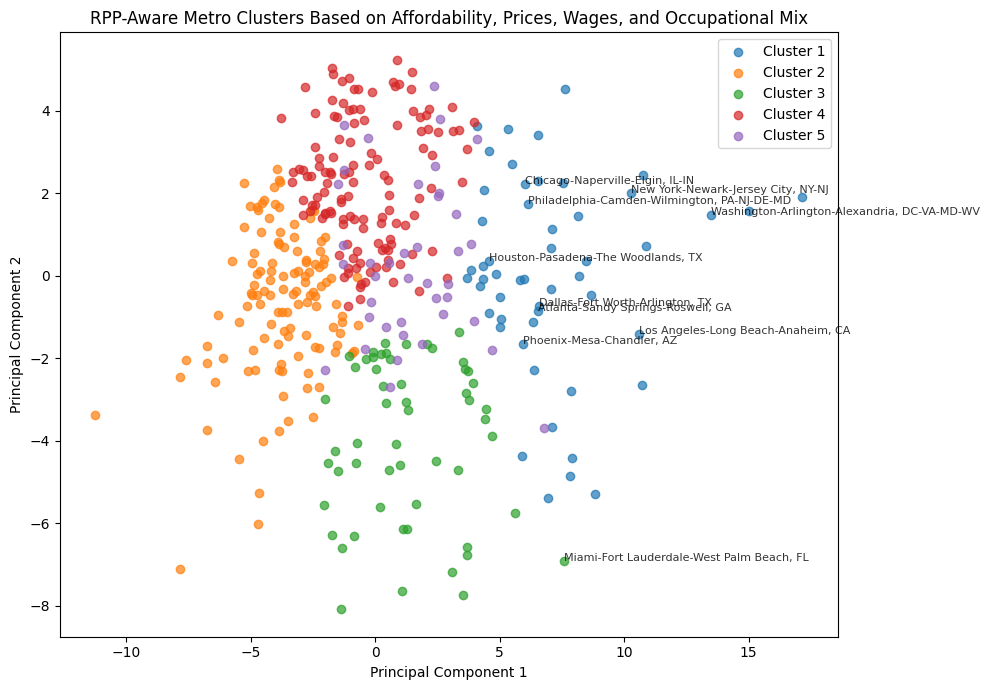

In [22]:
plt.figure(figsize=(10, 7))

for cluster_id, group in metro_profile.groupby("metro_cluster"):
    plt.scatter(
        group["pca_1"],
        group["pca_2"],
        alpha=0.7,
        label=f"Cluster {cluster_id}",
    )

largest_metros = metro_profile.sort_values("population", ascending=False).head(10)

for _, row in largest_metros.iterrows():
    plt.annotate(
        row["bls_msa_name"],
        (row["pca_1"], row["pca_2"]),
        fontsize=8,
        alpha=0.8,
    )

plt.title("RPP-Aware Metro Clusters Based on Affordability, Prices, Wages, and Occupational Mix")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_metro_clusters_pca_rpp_aware.png", dpi=150)
plt.show()

The PCA plot shows the five metro clusters in two dimensions. The first two principal components explain about **47%** of the variation in the standardized metro-profile features.

Large, expensive metros tend to separate from lower-cost metros. The labeled metros, such as New York, Los Angeles, San Francisco, Seattle, Chicago, Dallas, Houston, Washington DC, and Miami, help show how major metros relate to the broader cluster structure.

The clusters give users a way to compare similar metros and understand the type of market they are looking at, even if groupings are not perfectly distinct.

## 7. Nearest-Neighbor Metro Similarity

This creates dashboard-ready nearest-neighbor recommendations.

For each metro, the table returns the most similar metros based on the same standardized RPP-aware features used for clustering.

In [23]:
N_NEIGHBORS = 10

nn = NearestNeighbors(
    n_neighbors=min(N_NEIGHBORS + 1, len(metro_profile)),
    metric="euclidean",
)

nn.fit(X_cluster_scaled)

distances, indices = nn.kneighbors(X_cluster_scaled)

metro_profile_reset = metro_profile.reset_index(drop=True)

nearest_rows = []

for source_pos in range(len(metro_profile_reset)):
    source_row = metro_profile_reset.iloc[source_pos]

    for rank in range(1, indices.shape[1]):
        neighbor_pos = indices[source_pos, rank]
        neighbor_row = metro_profile_reset.iloc[neighbor_pos]

        nearest_rows.append({
            "source_cbsa_code": source_row["cbsa_code"],
            "source_metro": source_row["bls_msa_name"],
            "source_cluster": source_row["metro_cluster"],
            "neighbor_rank": rank,
            "neighbor_cbsa_code": neighbor_row["cbsa_code"],
            "neighbor_metro": neighbor_row["bls_msa_name"],
            "neighbor_cluster": neighbor_row["metro_cluster"],
            "distance": distances[source_pos, rank],
            "neighbor_annual_rent": neighbor_row["annual_rent"],
            "neighbor_rpp_all_items": neighbor_row["rpp_all_items"],
            "neighbor_rpp_housing": neighbor_row["rpp_services_housing"],
            "neighbor_median_household_income": neighbor_row["median_household_income"],
            "neighbor_real_household_income": neighbor_row["real_median_household_income"],
            "neighbor_mean_real_occ_wage": neighbor_row["mean_real_occ_wage"],
            "neighbor_mean_real_income_after_rent": neighbor_row["mean_real_income_after_rent"],
            "neighbor_mean_rent_burden": neighbor_row["mean_rent_burden"],
            "neighbor_share_high_lq": neighbor_row["share_high_lq"],
        })

nearest_metros = pd.DataFrame(nearest_rows)
nearest_metros.to_csv(NEAREST_METROS_CSV_PATH, index=False)

joblib.dump(
    {
        "nearest_neighbors": nn,
        "metro_profile": metro_profile_reset,
        "features": cluster_features,
        "latest_year": latest_year,
    },
    MODEL_DIR / "nearest_neighbor_metro_model.joblib",
)

print_shape("Nearest-neighbor metro table", nearest_metros)
print(f"Saved: {NEAREST_METROS_CSV_PATH}")

display(nearest_metros.head(20))

Nearest-neighbor metro table: 3,930 rows × 17 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/nearest_metros_latest.csv


,source_cbsa_code,source_metro,source_cluster,neighbor_rank,neighbor_cbsa_code,neighbor_metro,neighbor_cluster,distance,neighbor_annual_rent,neighbor_rpp_all_items,neighbor_rpp_housing,neighbor_median_household_income,neighbor_real_household_income,neighbor_mean_real_occ_wage,neighbor_mean_real_income_after_rent,neighbor_mean_rent_burden,neighbor_share_high_lq
0,10180,"Abilene, TX",2,1,41660,"San Angelo, TX",2,2.555761,13860.0,92.453,81.442,68419.0,74004.088564,58094.478811,43103.077775,0.308914,0.339207
1,10180,"Abilene, TX",2,2,31180,"Lubbock, TX",3,3.129804,13908.0,91.317,76.357,63629.0,69679.249209,60446.155025,45215.694104,0.302625,0.279487
2,10180,"Abilene, TX",2,3,11100,"Amarillo, TX",2,3.198488,13032.0,91.820,78.380,69611.0,75812.459159,61035.469241,46842.482964,0.280383,0.276786
3,10180,"Abilene, TX",2,4,48660,"Wichita Falls, TX",2,3.340391,11940.0,89.513,68.208,65379.0,73038.553059,60039.527016,46700.682379,0.268036,0.337449
4,10180,"Abilene, TX",2,5,17300,"Clarksville, TN-KY",2,3.438914,14484.0,90.947,73.801,68967.0,75832.078023,62072.269197,46146.510239,0.305392,0.336634
5,10180,"Abilene, TX",2,6,41540,"Salisbury, MD",2,3.763342,15288.0,95.617,87.212,73802.0,77185.019400,64197.919826,48209.131221,0.297659,0.398340
6,10180,"Abilene, TX",2,7,47380,"Waco, TX",4,3.808794,13812.0,92.550,83.531,66205.0,71534.305781,63271.508352,48347.683393,0.285156,0.262108
7,10180,"Abilene, TX",2,8,47020,"Victoria, TX",2,3.840703,13812.0,89.839,69.318,70236.0,78179.855074,60374.087467,44999.918120,0.304401,0.402062
8,10180,"Abilene, TX",2,9,28660,"Killeen-Temple, TX",2,4.060758,14604.0,91.132,77.884,69923.0,76727.164991,62653.039640,46627.933201,0.308148,0.301587
9,10180,"Abilene, TX",2,10,43340,"Shreveport-Bossier City, LA",2,4.247640,12168.0,84.766,52.286,55925.0,65975.744992,63475.728213,49120.916142,0.277967,0.388406


The nearest-neighbor table creates dashboard-ready metro recommendations. For each source metro, the table identifies the most similar metros using the same standardized RPP-aware features used for clustering.

This is useful because a user may not only want the “best” metro. They may want alternatives to a familiar city.

For example, if a user selects New York, similar metros include places like Los Angeles, Sacramento, Seattle, Minneapolis, Chicago, Philadelphia, Baltimore, Portland, Boston, and Denver. These are not identical cities, but they share broad similarities in scale, price level, rent, wages, and occupational mix.

This feature can support a dashboard section like:

> “If you are considering this metro, here are similar metros to compare.”

In [24]:
example_source_metro = metro_profile.sort_values("population", ascending=False).iloc[0]["bls_msa_name"]

print(f"Example source metro: {example_source_metro}")

display(
    nearest_metros
    .loc[nearest_metros["source_metro"] == example_source_metro]
    .sort_values("neighbor_rank")
)

Example source metro: New York-Newark-Jersey City, NY-NJ


,source_cbsa_code,source_metro,source_cluster,neighbor_rank,neighbor_cbsa_code,neighbor_metro,neighbor_cluster,distance,neighbor_annual_rent,neighbor_rpp_all_items,neighbor_rpp_housing,neighbor_median_household_income,neighbor_real_household_income,neighbor_mean_real_occ_wage,neighbor_mean_real_income_after_rent,neighbor_mean_rent_burden,neighbor_share_high_lq
2530,35620,"New York-Newark-Jersey City, NY-NJ",1,1,31080,"Los Angeles-Long Beach-Anaheim, CA",1,5.463845,24756.0,113.566,170.433,95958.0,84495.359527,66908.417665,45109.639862,0.391403,0.267882
2531,35620,"New York-Newark-Jersey City, NY-NJ",1,2,40900,"Sacramento-Roseville-Folsom, CA",1,5.764098,21828.0,106.670,130.230,97188.0,91110.902784,72284.309981,51821.199453,0.340142,0.252322
2532,35620,"New York-Newark-Jersey City, NY-NJ",1,3,42660,"Seattle-Tacoma-Bellevue, WA",1,6.365317,24000.0,111.133,151.314,115177.0,103638.883140,73204.442725,51608.697087,0.346299,0.272861
2533,35620,"New York-Newark-Jersey City, NY-NJ",1,4,33460,"Minneapolis-St. Paul-Bloomington, MN-WI",1,6.411509,17280.0,104.822,111.838,99833.0,95240.502948,69614.096358,53129.007350,0.277494,0.199695
2534,35620,"New York-Newark-Jersey City, NY-NJ",1,5,16980,"Chicago-Naperville-Elgin, IL-IN",1,6.511859,17160.0,103.595,112.010,90887.0,87732.998697,67456.486543,50891.980534,0.289628,0.192475
2535,35620,"New York-Newark-Jersey City, NY-NJ",1,6,37980,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",1,6.756844,17760.0,102.554,113.141,91289.0,89015.543031,66967.563280,49649.857486,0.305247,0.202201
2536,35620,"New York-Newark-Jersey City, NY-NJ",1,7,12580,"Baltimore-Columbia-Towson, MD",1,6.812585,19332.0,104.487,118.194,99470.0,95198.445740,67308.791327,48806.968134,0.328441,0.306709
2537,35620,"New York-Newark-Jersey City, NY-NJ",1,8,38900,"Portland-Vancouver-Hillsboro, OR-WA",1,6.943213,20688.0,105.421,125.114,97436.0,92425.607801,69569.500444,49945.326892,0.326810,0.306306
2538,35620,"New York-Newark-Jersey City, NY-NJ",1,9,14460,"Boston-Cambridge-Newton, MA-NH",1,7.248002,24276.0,108.266,148.424,115863.0,107016.976706,71208.528841,48785.976978,0.374282,0.292868
2539,35620,"New York-Newark-Jersey City, NY-NJ",1,10,19740,"Denver-Aurora-Centennial, CO",1,7.711753,22488.0,105.782,146.919,105762.0,99981.093192,68715.380167,47456.564868,0.361323,0.282714


## 8. Build Supervised Forecasting Dataset

The supervised modeling dataset predicts target-year outcomes using only prior-year information. For a target year `t`, the features come from `t-1` and earlier.

This is important because it avoids data leakage. If we used 2024 features to predict 2024 outcomes, the model would not be a real forecast. By using lagged features, the model is closer to the actual dashboard use case: using what we know now to estimate next-year affordability.

The target years are 2021, 2022, 2023, and 2024. The notebook uses a time-based split:

- Train: 2021–2022
- Validation: 2023
- Test: 2024

This is more appropriate than a random split because the same occupation-metro pairs appear across years.

In [25]:
panel = df_all.to_pandas()

panel["cbsa_code"] = panel["cbsa_code"].astype(str).str.zfill(5)
panel["occ_code"] = panel["occ_code"].astype(str)
panel["occ_major"] = panel["occ_code"].str.slice(0, 2)

panel = panel.sort_values(["cbsa_code", "occ_code", "year"]).reset_index(drop=True)

panel_keys = ["cbsa_code", "occ_code"]

lag_source_cols = [
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "cost_adjusted_rent_burden_median",
    "real_income_after_rent_median",

    "wage_annual_median",
    "wage_annual_mean",
    "real_wage_annual_median",
    "real_wage_annual_mean",

    "annual_rent",
    "median_household_income",
    "real_median_household_income",
    "population",

    "tot_emp",
    "jobs_1000",
    "loc_quotient",
    "log_tot_emp",

    "rpp_all_items",
    "rpp_goods",
    "rpp_services_housing",
    "rpp_services_other",
    "rpp_all_items_index",
]

lag_source_cols = [c for c in lag_source_cols if c in panel.columns]

for col in lag_source_cols:
    panel[f"{col}_lag1"] = panel.groupby(panel_keys)[col].shift(1)
    panel[f"{col}_lag2"] = panel.groupby(panel_keys)[col].shift(2)

panel["rent_burden_change_lag1"] = (
    panel["rent_to_median_wage_ratio_lag1"]
    - panel["rent_to_median_wage_ratio_lag2"]
)

panel["cost_adjusted_rent_burden_change_lag1"] = (
    panel["cost_adjusted_rent_burden_median_lag1"]
    - panel["cost_adjusted_rent_burden_median_lag2"]
)

panel["real_income_after_rent_change_lag1"] = (
    panel["real_income_after_rent_median_lag1"]
    - panel["real_income_after_rent_median_lag2"]
)

panel["wage_growth_lag1"] = safe_divide(
    panel["wage_annual_median_lag1"],
    panel["wage_annual_median_lag2"],
) - 1

panel["real_wage_growth_lag1"] = safe_divide(
    panel["real_wage_annual_median_lag1"],
    panel["real_wage_annual_median_lag2"],
) - 1

panel["rent_growth_lag1"] = safe_divide(
    panel["annual_rent_lag1"],
    panel["annual_rent_lag2"],
) - 1

panel["employment_growth_lag1"] = safe_divide(
    panel["tot_emp_lag1"],
    panel["tot_emp_lag2"],
) - 1

panel["lq_change_lag1"] = (
    panel["loc_quotient_lag1"]
    - panel["loc_quotient_lag2"]
)

panel["rpp_all_items_change_lag1"] = (
    panel["rpp_all_items_lag1"]
    - panel["rpp_all_items_lag2"]
)

panel["rpp_housing_change_lag1"] = (
    panel["rpp_services_housing_lag1"]
    - panel["rpp_services_housing_lag2"]
)

panel = panel.replace([np.inf, -np.inf], np.nan)

print_shape("Lagged supervised panel", panel)

display(
    panel[
        [
            "year",
            "cbsa_code",
            "bls_msa_name",
            "occ_code",
            "occ_title",
            "rent_to_median_wage_ratio",
            "real_income_after_rent_median",
            "rpp_all_items",
            "rent_to_median_wage_ratio_lag1",
            "real_income_after_rent_median_lag1",
            "rpp_all_items_lag1",
        ]
    ].head()
)

Lagged supervised panel: 689,932 rows × 110 columns


,year,cbsa_code,bls_msa_name,occ_code,occ_title,rent_to_median_wage_ratio,real_income_after_rent_median,rpp_all_items,rent_to_median_wage_ratio_lag1,real_income_after_rent_median_lag1,rpp_all_items_lag1
0,2023,10180,"Abilene, TX",11-1011,Chief Executives,0.064940,209305.927385,90.394,NaN,NaN,NaN
1,2024,10180,"Abilene, TX",11-1011,Chief Executives,0.077129,181297.861980,90.364,0.064940,209305.927385,90.394
2,2020,10180,"Abilene, TX",11-1021,General and Operations Managers,0.158950,63852.833031,90.292,NaN,NaN,NaN
3,2021,10180,"Abilene, TX",11-1021,General and Operations Managers,0.153332,68592.309790,91.675,0.158950,63852.833031,90.292
4,2022,10180,"Abilene, TX",11-1021,General and Operations Managers,0.172319,66123.287372,91.526,0.153332,68592.309790,91.675


## 9. Regression Features and Model Specifications

In [26]:
numeric_features = [
    "rent_to_median_wage_ratio_lag1",
    "median_wage_to_rent_ratio_lag1",
    "cost_adjusted_rent_burden_median_lag1",
    "real_income_after_rent_median_lag1",

    "wage_annual_median_lag1",
    "wage_annual_mean_lag1",
    "real_wage_annual_median_lag1",
    "real_wage_annual_mean_lag1",

    "annual_rent_lag1",
    "median_household_income_lag1",
    "real_median_household_income_lag1",
    "population_lag1",

    "tot_emp_lag1",
    "jobs_1000_lag1",
    "loc_quotient_lag1",
    "log_tot_emp_lag1",

    "rpp_all_items_lag1",
    "rpp_goods_lag1",
    "rpp_services_housing_lag1",
    "rpp_services_other_lag1",

    "rent_burden_change_lag1",
    "cost_adjusted_rent_burden_change_lag1",
    "real_income_after_rent_change_lag1",
    "wage_growth_lag1",
    "real_wage_growth_lag1",
    "rent_growth_lag1",
    "employment_growth_lag1",
    "lq_change_lag1",
    "rpp_all_items_change_lag1",
    "rpp_housing_change_lag1",
]

numeric_features = [c for c in numeric_features if c in panel.columns]

categorical_features = [
    "occ_major",
    "prim_state",
]

categorical_features = [c for c in categorical_features if c in panel.columns]

feature_cols = numeric_features + categorical_features

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['rent_to_median_wage_ratio_lag1', 'median_wage_to_rent_ratio_lag1', 'cost_adjusted_rent_burden_median_lag1', 'real_income_after_rent_median_lag1', 'wage_annual_median_lag1', 'wage_annual_mean_lag1', 'real_wage_annual_median_lag1', 'real_wage_annual_mean_lag1', 'annual_rent_lag1', 'median_household_income_lag1', 'real_median_household_income_lag1', 'population_lag1', 'tot_emp_lag1', 'jobs_1000_lag1', 'loc_quotient_lag1', 'log_tot_emp_lag1', 'rpp_all_items_lag1', 'rpp_goods_lag1', 'rpp_services_housing_lag1', 'rpp_services_other_lag1', 'rent_burden_change_lag1', 'cost_adjusted_rent_burden_change_lag1', 'real_income_after_rent_change_lag1', 'wage_growth_lag1', 'real_wage_growth_lag1', 'rent_growth_lag1', 'employment_growth_lag1', 'lq_change_lag1', 'rpp_all_items_change_lag1', 'rpp_housing_change_lag1']

Categorical features:
['occ_major', 'prim_state']


In [27]:
def make_preprocessors() -> tuple[ColumnTransformer, ColumnTransformer]:
    linear_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
        ],
        remainder="drop",
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
        ],
        remainder="drop",
    )

    return linear_preprocessor, tree_preprocessor


def make_ridge_pipeline(alpha: float = 1.0) -> Pipeline:
    linear_preprocessor, _ = make_preprocessors()

    return Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", Ridge(alpha=alpha)),
        ]
    )


def make_random_forest_pipeline(
    *,
    n_estimators: int = 150,
    max_depth: int | None = 16,
    min_samples_leaf: int = 20,
    max_samples: float = 0.75,
) -> Pipeline:
    _, tree_preprocessor = make_preprocessors()

    return Pipeline(
        steps=[
            ("preprocess", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_samples=max_samples,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_model_specs() -> dict[str, Pipeline]:
    linear_preprocessor, _ = make_preprocessors()

    return {
        "Linear Regression": Pipeline(
            steps=[
                ("preprocess", linear_preprocessor),
                ("model", LinearRegression()),
            ]
        ),
        "Ridge Regression": make_ridge_pipeline(alpha=1.0),
        "Random Forest": make_random_forest_pipeline(
            n_estimators=150,
            max_depth=16,
            min_samples_leaf=20,
            max_samples=0.75,
        ),
    }


def tune_ridge_on_validation(
    *,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    target_name: str,
    target_label: str,
) -> pd.DataFrame:
    alpha_grid = [0.1, 1.0, 10.0, 100.0]
    tuning_rows = []

    X_train = train_df[feature_cols]
    y_train = train_df[target_name]
    X_val = val_df[feature_cols]
    y_val = val_df[target_name]

    for alpha in alpha_grid:
        model = make_ridge_pipeline(alpha=alpha)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        tuning_rows.append({
            "target": target_label,
            "model": "Ridge Regression",
            "alpha": alpha,
            "n_estimators": np.nan,
            "max_depth": np.nan,
            "min_samples_leaf": np.nan,
            "max_samples": np.nan,
            **regression_metrics(y_val, val_pred),
        })

    return pd.DataFrame(tuning_rows).sort_values("mae")


def tune_random_forest_on_validation(
    *,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    target_name: str,
    target_label: str,
) -> pd.DataFrame:
    rf_grid = [
        {
            "n_estimators": 60,
            "max_depth": 10,
            "min_samples_leaf": 50,
            "max_samples": 0.75,
        },
        {
            "n_estimators": 100,
            "max_depth": 14,
            "min_samples_leaf": 30,
            "max_samples": 0.75,
        },
        {
            "n_estimators": 120,
            "max_depth": 16,
            "min_samples_leaf": 20,
            "max_samples": 0.75,
        },
    ]

    tuning_rows = []

    X_train = train_df[feature_cols]
    y_train = train_df[target_name]
    X_val = val_df[feature_cols]
    y_val = val_df[target_name]

    for params in rf_grid:
        model = make_random_forest_pipeline(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        tuning_rows.append({
            "target": target_label,
            "model": "Random Forest",
            "alpha": np.nan,
            **params,
            **regression_metrics(y_val, val_pred),
        })

    return pd.DataFrame(tuning_rows).sort_values("mae")


def evaluate_prediction_rows(
    rows: list[dict],
    target_label: str,
    model_name: str,
    split_name: str,
    y_true,
    y_pred,
) -> None:
    metrics = regression_metrics(y_true, y_pred)
    rows.append({
        "target": target_label,
        "model": model_name,
        "split": split_name,
        **metrics,
    })

### Feature and Model Specifications

The regression features include lagged wages, lagged rent, lagged RPP variables, lagged affordability metrics, employment variables, location quotient, occupation categories, and metro/state identifiers.

The models are designed to compare simple baselines against more flexible machine-learning approaches:

- A **persistence baseline**, which predicts that next year equals last year.
- A **train-mean baseline**, which gives a weak reference point.
- **Linear regression** and **ridge regression**, which are interpretable linear models.
- **Random forest**, which can capture nonlinear relationships and interactions.
- Tuned ridge and tuned random forest models.

The persistence baseline is especially important because affordability metrics often change slowly over time. Any complex model should be compared against this straightforward benchmark.

## 10. Reusable Regression Experiment Function

This function trains and evaluates:

- persistence baseline
- train-mean baseline
- linear regression
- ridge regression
- random forest

It uses a time-based split:

- Train: earliest target years
- Validation: second-most-recent target year
- Test: most recent target year

In [28]:
def run_regression_experiment(
    *,
    panel_df: pd.DataFrame,
    target_col: str,
    target_label: str,
    target_suffix: str,
    persistence_lag_col: str,
    required_lag_cols: list[str],
) -> dict:
    target_name = f"target_{target_suffix}"

    model_df = panel_df.copy()
    model_df[target_name] = model_df[target_col]
    model_df["target_year"] = model_df["year"]

    required_cols = [target_name, persistence_lag_col] + required_lag_cols
    required_cols = [c for c in required_cols if c in model_df.columns]

    model_df = model_df.dropna(subset=required_cols).copy()
    model_df = model_df.replace([np.inf, -np.inf], np.nan)

    available_target_years = sorted(model_df["target_year"].dropna().unique())

    if len(available_target_years) >= 4:
        test_year = available_target_years[-1]
        val_year = available_target_years[-2]
        train_years = available_target_years[:-2]
    elif len(available_target_years) == 3:
        test_year = available_target_years[-1]
        val_year = available_target_years[-2]
        train_years = available_target_years[:-2]
    else:
        test_year = available_target_years[-1]
        val_year = None
        train_years = available_target_years[:-1]

    train_df = model_df[model_df["target_year"].isin(train_years)].copy()

    if val_year is not None:
        val_df = model_df[model_df["target_year"] == val_year].copy()
    else:
        val_df = pd.DataFrame(columns=model_df.columns)

    test_df = model_df[model_df["target_year"] == test_year].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_name]

    X_val = val_df[feature_cols] if len(val_df) > 0 else None
    y_val = val_df[target_name] if len(val_df) > 0 else None

    X_test = test_df[feature_cols]
    y_test = test_df[target_name]

    print("=" * 90)
    print(f"Regression experiment: {target_label}")
    print("=" * 90)
    print(f"Available target years: {available_target_years}")
    print(f"Train years: {train_years}")
    print(f"Validation year: {val_year}")
    print(f"Test year: {test_year}")
    print_shape("Modeling dataset", model_df)
    print_shape("Train", train_df)
    print_shape("Validation", val_df)
    print_shape("Test", test_df)

    metrics_rows = []

    evaluate_prediction_rows(
        metrics_rows,
        target_label,
        "Persistence Baseline",
        "train",
        y_train,
        train_df[persistence_lag_col],
    )

    if len(val_df) > 0:
        evaluate_prediction_rows(
            metrics_rows,
            target_label,
            "Persistence Baseline",
            "val",
            y_val,
            val_df[persistence_lag_col],
        )

    evaluate_prediction_rows(
        metrics_rows,
        target_label,
        "Persistence Baseline",
        "test",
        y_test,
        test_df[persistence_lag_col],
    )

    train_mean_prediction = y_train.mean()

    evaluate_prediction_rows(
        metrics_rows,
        target_label,
        "Train Mean Baseline",
        "train",
        y_train,
        np.repeat(train_mean_prediction, len(y_train)),
    )

    if len(val_df) > 0:
        evaluate_prediction_rows(
            metrics_rows,
            target_label,
            "Train Mean Baseline",
            "val",
            y_val,
            np.repeat(train_mean_prediction, len(y_val)),
        )

    evaluate_prediction_rows(
        metrics_rows,
        target_label,
        "Train Mean Baseline",
        "test",
        y_test,
        np.repeat(train_mean_prediction, len(y_test)),
    )

    model_specs = make_model_specs()
    fitted_models = {}
    tuning_results = []

    for model_name, pipeline in model_specs.items():
        print("-" * 90)
        print(f"Training {model_name} for {target_label}")
        print("-" * 90)

        pipeline.fit(X_train, y_train)
        fitted_models[model_name] = pipeline

        train_pred = pipeline.predict(X_train)
        evaluate_prediction_rows(metrics_rows, target_label, model_name, "train", y_train, train_pred)

        if len(val_df) > 0:
            val_pred = pipeline.predict(X_val)
            evaluate_prediction_rows(metrics_rows, target_label, model_name, "val", y_val, val_pred)

        test_pred = pipeline.predict(X_test)
        evaluate_prediction_rows(metrics_rows, target_label, model_name, "test", y_test, test_pred)

    tuned_model_specs = {}

    if len(val_df) > 0:
        print("=" * 90)
        print(f"Validation-based hyperparameter tuning for {target_label}")
        print("=" * 90)

        ridge_tuning = tune_ridge_on_validation(
            train_df=train_df,
            val_df=val_df,
            target_name=target_name,
            target_label=target_label,
        )

        rf_tuning = tune_random_forest_on_validation(
            train_df=train_df,
            val_df=val_df,
            target_name=target_name,
            target_label=target_label,
        )

        tuning_results = pd.concat([ridge_tuning, rf_tuning], axis=0, ignore_index=True)

        tuning_path = MODELING_DIR / f"hyperparameter_tuning_{target_suffix}.csv"
        tuning_results.to_csv(tuning_path, index=False)

        print(f"Saved hyperparameter tuning results: {tuning_path}")
        display(tuning_results.sort_values(["model", "mae"]))

        best_ridge_alpha = float(
            ridge_tuning.sort_values("mae").iloc[0]["alpha"]
        )

        best_rf_row = rf_tuning.sort_values("mae").iloc[0]

        tuned_model_specs["Tuned Ridge Regression"] = make_ridge_pipeline(
            alpha=best_ridge_alpha
        )

        tuned_model_specs["Tuned Random Forest"] = make_random_forest_pipeline(
            n_estimators=int(best_rf_row["n_estimators"]),
            max_depth=int(best_rf_row["max_depth"]),
            min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
            max_samples=float(best_rf_row["max_samples"]),
        )

        for model_name, pipeline in tuned_model_specs.items():
            print("-" * 90)
            print(f"Training {model_name} for {target_label}")
            print("-" * 90)

            pipeline.fit(X_train, y_train)
            fitted_models[model_name] = pipeline

            train_pred = pipeline.predict(X_train)
            evaluate_prediction_rows(metrics_rows, target_label, model_name, "train", y_train, train_pred)

            val_pred = pipeline.predict(X_val)
            evaluate_prediction_rows(metrics_rows, target_label, model_name, "val", y_val, val_pred)

            test_pred = pipeline.predict(X_test)
            evaluate_prediction_rows(metrics_rows, target_label, model_name, "test", y_test, test_pred)

    all_model_specs = {**model_specs, **tuned_model_specs}

    metrics_df = (
        pd.DataFrame(metrics_rows)
        .sort_values(["target", "split", "mae", "rmse"])
        .reset_index(drop=True)
    )

    if len(val_df) > 0:
        selection_split = "val"
    else:
        selection_split = "test"

    candidate_model_names = list(all_model_specs.keys())

    best_model_name = (
        metrics_df
        .loc[
            (metrics_df["split"] == selection_split)
            & (metrics_df["model"].isin(candidate_model_names))
        ]
        .sort_values("mae")
        .iloc[0]["model"]
    )

    print(f"Best fitted model by {selection_split} MAE: {best_model_name}")

    if len(val_df) > 0:
        train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
    else:
        train_val_df = train_df.copy()

    X_train_val = train_val_df[feature_cols]
    y_train_val = train_val_df[target_name]

    final_model = clone(all_model_specs[best_model_name])
    final_model.fit(X_train_val, y_train_val)

    final_test_pred = final_model.predict(X_test)
    final_test_metrics = regression_metrics(y_test, final_test_pred)

    final_metrics_row = {
        "target": target_label,
        "model": f"{best_model_name} Refit Train+Val",
        "split": "test",
        **final_test_metrics,
    }

    final_metrics_df = pd.concat(
        [metrics_df, pd.DataFrame([final_metrics_row])],
        axis=0,
        ignore_index=True,
    )

    metrics_path = MODELING_DIR / f"regression_model_metrics_{target_suffix}.csv"
    predictions_path = MODELING_DIR / f"regression_test_predictions_{target_suffix}.csv"
    final_model_path = MODEL_DIR / f"best_regression_model_{target_suffix}.joblib"

    final_metrics_df.to_csv(metrics_path, index=False)
    joblib.dump(final_model, final_model_path)

    context_cols = [
        "target_year",
        "cbsa_code",
        "bls_msa_name",
        "prim_state",
        "occ_code",
        "occ_title",
        target_name,
        persistence_lag_col,
        "wage_annual_median_lag1",
        "real_wage_annual_median_lag1",
        "annual_rent_lag1",
        "rpp_all_items_lag1",
        "real_income_after_rent_median_lag1",
        "tot_emp_lag1",
        "loc_quotient_lag1",
    ]

    context_cols = list(dict.fromkeys([c for c in context_cols if c in test_df.columns]))

    test_predictions = test_df[context_cols].copy()
    test_predictions["target_label"] = target_label
    test_predictions["persistence_prediction"] = test_df[persistence_lag_col].to_numpy()
    test_predictions["model_prediction"] = final_test_pred
    test_predictions["model_error"] = test_predictions["model_prediction"] - test_predictions[target_name]
    test_predictions["absolute_error"] = test_predictions["model_error"].abs()

    test_predictions.to_csv(predictions_path, index=False)

    print(f"Saved metrics: {metrics_path}")
    print(f"Saved test predictions: {predictions_path}")
    print(f"Saved final model: {final_model_path}")

    display(final_metrics_df.sort_values(["split", "mae"]))

    return {
        "target_col": target_col,
        "target_label": target_label,
        "target_suffix": target_suffix,
        "target_name": target_name,
        "persistence_lag_col": persistence_lag_col,
        "available_target_years": available_target_years,
        "train_years": train_years,
        "val_year": val_year,
        "test_year": test_year,
        "model_df": model_df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "metrics": final_metrics_df,
        "test_predictions": test_predictions,
        "fitted_models": fitted_models,
        "tuning_results": tuning_results,
        "best_model_name": best_model_name,
        "final_model": final_model,
        "metrics_path": metrics_path,
        "predictions_path": predictions_path,
        "final_model_path": final_model_path,
    }

The reusable regression function keeps the modeling process consistent across targets. Each target is evaluated with the same split strategy, baseline models, machine-learning models, and metrics.

The main evaluation metrics are:

- **MAE**, which measures the average absolute prediction error.
- **RMSE**, which penalizes larger errors more strongly.
- **R²**, which measures the proportion of variance explained by the model.

Using multiple metrics is important because a model can perform well on one metric but not another. For example, a model might reduce large errors and improve RMSE while still having similar or slightly worse MAE than a persistence baseline.

## 11. Regression Experiment 1: Predict Next-Year Rent Burden

Target:

- `rent_to_median_wage_ratio`

Lower values indicate better housing affordability.

This keeps the original modeling task while adding BEA RPP features as predictors.

In [29]:
rent_burden_result = run_regression_experiment(
    panel_df=panel,
    target_col="rent_to_median_wage_ratio",
    target_label="Rent burden: annual rent / annual median wage",
    target_suffix="rent_burden",
    persistence_lag_col="rent_to_median_wage_ratio_lag1",
    required_lag_cols=[
        "wage_annual_median_lag1",
        "annual_rent_lag1",
        "rpp_all_items_lag1",
    ],
)

Regression experiment: Rent burden: annual rent / annual median wage
Available target years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train years: [np.int64(2021), np.int64(2022)]
Validation year: 2023
Test year: 2024
Modeling dataset: 460,114 rows × 112 columns
Train: 218,279 rows × 112 columns
Validation: 120,269 rows × 112 columns
Test: 121,566 rows × 112 columns
------------------------------------------------------------------------------------------
Training Linear Regression for Rent burden: annual rent / annual median wage
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
Training Ridge Regression for Rent burden: annual rent / annual median wage
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------

,target,model,alpha,n_estimators,max_depth,min_samples_leaf,max_samples,mae,rmse,r2
4,Rent burden: annual rent / annual median wage,Random Forest,NaN,60.0,10.0,50.0,0.75,0.022884,0.033670,0.930322
5,Rent burden: annual rent / annual median wage,Random Forest,NaN,100.0,14.0,30.0,0.75,0.022893,0.033476,0.931124
6,Rent burden: annual rent / annual median wage,Random Forest,NaN,120.0,16.0,20.0,0.75,0.022941,0.033461,0.931186
0,Rent burden: annual rent / annual median wage,Ridge Regression,0.1,NaN,NaN,NaN,NaN,0.024512,0.034806,0.925542
1,Rent burden: annual rent / annual median wage,Ridge Regression,1.0,NaN,NaN,NaN,NaN,0.024539,0.034826,0.925456
2,Rent burden: annual rent / annual median wage,Ridge Regression,10.0,NaN,NaN,NaN,NaN,0.024553,0.034824,0.925467
3,Rent burden: annual rent / annual median wage,Ridge Regression,100.0,NaN,NaN,NaN,NaN,0.024554,0.034790,0.925609


------------------------------------------------------------------------------------------
Training Tuned Ridge Regression for Rent burden: annual rent / annual median wage
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
Training Tuned Random Forest for Rent burden: annual rent / annual median wage
------------------------------------------------------------------------------------------
Best fitted model by val MAE: Tuned Random Forest
Saved metrics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_model_metrics_rent_burden.csv
Saved test predictions: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_test_predictions_rent_burden.csv
Saved final model: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/best_regression_model_rent_burden.joblib


,target,model,split,mae,rmse,r2
0,Rent burden: annual rent / annual median wage,Persistence Baseline,test,0.020009,0.033236,0.932479
21,Rent burden: annual rent / annual median wage,Tuned Random Forest Refit Train+Val,test,0.020754,0.032305,0.936209
1,Rent burden: annual rent / annual median wage,Random Forest,test,0.022869,0.033544,0.931223
2,Rent burden: annual rent / annual median wage,Tuned Random Forest,test,0.022918,0.033772,0.930284
3,Rent burden: annual rent / annual median wage,Linear Regression,test,0.025433,0.035717,0.922022
4,Rent burden: annual rent / annual median wage,Tuned Ridge Regression,test,0.025440,0.035725,0.921989
5,Rent burden: annual rent / annual median wage,Ridge Regression,test,0.025465,0.035753,0.921865
6,Rent burden: annual rent / annual median wage,Train Mean Baseline,test,0.101760,0.127910,-0.000072
7,Rent burden: annual rent / annual median wage,Random Forest,train,0.020441,0.032020,0.938729
8,Rent burden: annual rent / annual median wage,Tuned Random Forest,train,0.022482,0.034999,0.926796


### Rent-Burden Modeling

The first modeling target is next-year rent burden:

`annual rent / annual median wage`

Where lower values indicate better affordability.

The results show that rent burden is highly persistent. The persistence baseline is extremely strong, with a 2024 test MAE of about **0.0200** and R² of about **0.9325**. This means that last year’s rent burden already explains most of this year’s rent burden.

The tuned random forest refit on train plus validation performs best on RMSE and R², with test RMSE around **0.0323** and R² around **0.9362**, but the persistence baseline is slightly better on MAE.

The conclusion is not that the model failed. The conclusion is that rent burden changes gradually over time. The random forest helps somewhat with larger errors, but the simplest predictor of last year’s value is already very hard to beat.

## 12. Regression Experiment 2: Predict Next-Year RPP-Adjusted Income After Rent

Target:

- `real_income_after_rent_median`

Higher values indicate more purchasing power after paying typical annual rent.

This target is the most direct use of BEA RPP because it adjusts remaining income by local price levels.

In [30]:
real_income_result = run_regression_experiment(
    panel_df=panel,
    target_col="real_income_after_rent_median",
    target_label="RPP-adjusted income after rent",
    target_suffix="real_income_after_rent",
    persistence_lag_col="real_income_after_rent_median_lag1",
    required_lag_cols=[
        "real_income_after_rent_median_lag1",
        "real_wage_annual_median_lag1",
        "annual_rent_lag1",
        "rpp_all_items_lag1",
    ],
)

Regression experiment: RPP-adjusted income after rent
Available target years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train years: [np.int64(2021), np.int64(2022)]
Validation year: 2023
Test year: 2024
Modeling dataset: 460,114 rows × 112 columns
Train: 218,279 rows × 112 columns
Validation: 120,269 rows × 112 columns
Test: 121,566 rows × 112 columns
------------------------------------------------------------------------------------------
Training Linear Regression for RPP-adjusted income after rent
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
Training Ridge Regression for RPP-adjusted income after rent
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
Training Random Forest for RPP-adjusted inco

,target,model,alpha,n_estimators,max_depth,min_samples_leaf,max_samples,mae,rmse,r2
4,RPP-adjusted income after rent,Random Forest,NaN,100.0,14.0,30.0,0.75,4567.101834,7695.266705,0.933497
5,RPP-adjusted income after rent,Random Forest,NaN,60.0,10.0,50.0,0.75,4567.150883,7717.628850,0.933110
6,RPP-adjusted income after rent,Random Forest,NaN,120.0,16.0,20.0,0.75,4568.026474,7689.826352,0.933591
0,RPP-adjusted income after rent,Ridge Regression,0.1,NaN,NaN,NaN,NaN,4796.623207,7815.928309,0.931395
1,RPP-adjusted income after rent,Ridge Regression,100.0,NaN,NaN,NaN,NaN,4800.613816,7832.013336,0.931113
2,RPP-adjusted income after rent,Ridge Regression,1.0,NaN,NaN,NaN,NaN,4802.636159,7822.897739,0.931273
3,RPP-adjusted income after rent,Ridge Regression,10.0,NaN,NaN,NaN,NaN,4806.765319,7828.834915,0.931169


------------------------------------------------------------------------------------------
Training Tuned Ridge Regression for RPP-adjusted income after rent
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
Training Tuned Random Forest for RPP-adjusted income after rent
------------------------------------------------------------------------------------------
Best fitted model by val MAE: Tuned Random Forest
Saved metrics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_model_metrics_real_income_after_rent.csv
Saved test predictions: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_test_predictions_real_income_after_rent.csv
Saved final model: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/best_regression_model_real_income_after_rent.joblib


,target,model,split,mae,rmse,r2
21,RPP-adjusted income after rent,Tuned Random Forest Refit Train+Val,test,4522.870067,7603.394339,0.937175
0,RPP-adjusted income after rent,Tuned Random Forest,test,4696.224514,7806.906000,0.933767
1,RPP-adjusted income after rent,Random Forest,test,4705.830380,7809.889941,0.933716
2,RPP-adjusted income after rent,Persistence Baseline,test,4733.409645,8128.086454,0.928205
3,RPP-adjusted income after rent,Linear Regression,test,4813.155256,7835.298122,0.933284
4,RPP-adjusted income after rent,Tuned Ridge Regression,test,4813.804842,7836.273385,0.933267
5,RPP-adjusted income after rent,Ridge Regression,test,4817.267231,7840.793631,0.933190
6,RPP-adjusted income after rent,Train Mean Baseline,test,22072.190228,30808.244268,-0.031462
7,RPP-adjusted income after rent,Random Forest,train,4163.103746,6837.284105,0.937837
8,RPP-adjusted income after rent,Tuned Random Forest,train,4334.014272,7093.879340,0.933083


### RPP-Adjusted Income-After-Rent Modeling

The second modeling target is next-year RPP-adjusted income after rent:

`(annual median wage - annual rent) / RPP index`

Where higher values indicate more purchasing power after paying typical annual rent.

This target gives the strongest modeling result. The tuned random forest refit on train plus validation performs best on the 2024 test set, with:

- MAE around **$4,523**
- RMSE around **$7,603**
- R² around **0.937**

This model beats the persistence baseline, which has MAE around **$4,733** and RMSE around **$8,128**.

That means the model adds predictive value beyond simply copying last year’s after-rent income. The improvement is not enormous because the target is still persistent, but it is meaningful enough to support short-term dashboard predictions.

## 13. Combined Regression Metrics

In [31]:
all_metrics = pd.concat(
    [
        rent_burden_result["metrics"],
        real_income_result["metrics"],
    ],
    axis=0,
    ignore_index=True,
)

all_metrics.to_csv(REGRESSION_METRICS_ALL_TARGETS_CSV_PATH, index=False)

print(f"Saved combined metrics: {REGRESSION_METRICS_ALL_TARGETS_CSV_PATH}")

display(
    all_metrics
    .sort_values(["target", "split", "mae"])
    .reset_index(drop=True)
)

Saved combined metrics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_model_metrics_all_targets.csv


,target,model,split,mae,rmse,r2
0,RPP-adjusted income after rent,Tuned Random Forest Refit Train+Val,test,4522.870067,7603.394339,0.937175
1,RPP-adjusted income after rent,Tuned Random Forest,test,4696.224514,7806.906000,0.933767
2,RPP-adjusted income after rent,Random Forest,test,4705.830380,7809.889941,0.933716
3,RPP-adjusted income after rent,Persistence Baseline,test,4733.409645,8128.086454,0.928205
4,RPP-adjusted income after rent,Linear Regression,test,4813.155256,7835.298122,0.933284
5,RPP-adjusted income after rent,Tuned Ridge Regression,test,4813.804842,7836.273385,0.933267
6,RPP-adjusted income after rent,Ridge Regression,test,4817.267231,7840.793631,0.933190
7,RPP-adjusted income after rent,Train Mean Baseline,test,22072.190228,30808.244268,-0.031462
8,RPP-adjusted income after rent,Random Forest,train,4163.103746,6837.284105,0.937837
9,RPP-adjusted income after rent,Tuned Random Forest,train,4334.014272,7093.879340,0.933083


### Combined Metrics Analysis

The combined metrics table makes it easier to compare both modeling targets.

For rent burden, the persistence baseline is very competitive and slightly better on MAE, while the tuned random forest refit is better on RMSE and R². This suggests that rent burden is stable and highly autoregressive.

For RPP-adjusted income after rent, the tuned random forest refit is the best overall model. It improves over persistence on MAE, RMSE, and R², which makes it the stronger predictive target for the dashboard.

The main modeling takeaway is that both outcomes are predictable, but they are predictable largely because career-city affordability is persistent over time. The forecasts should therefore be presented as short-term signals, not exact future values.

## 14. Test Prediction Diagnostics

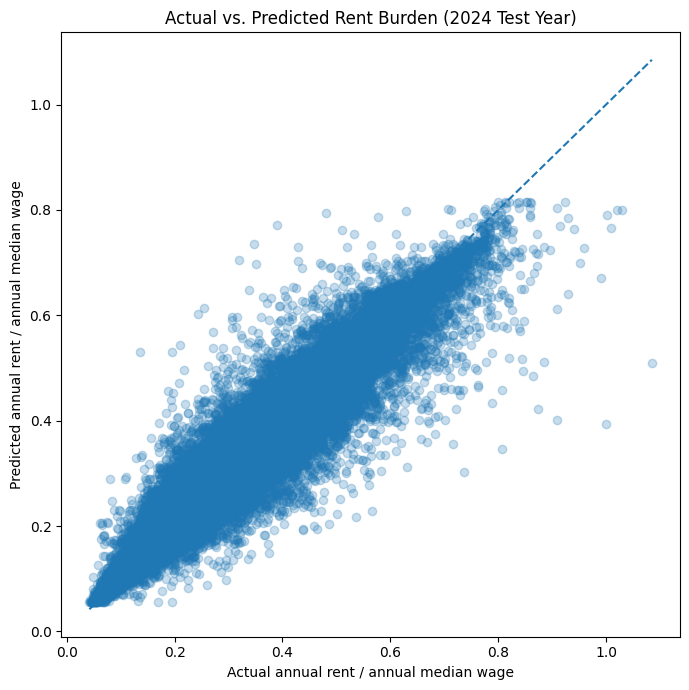

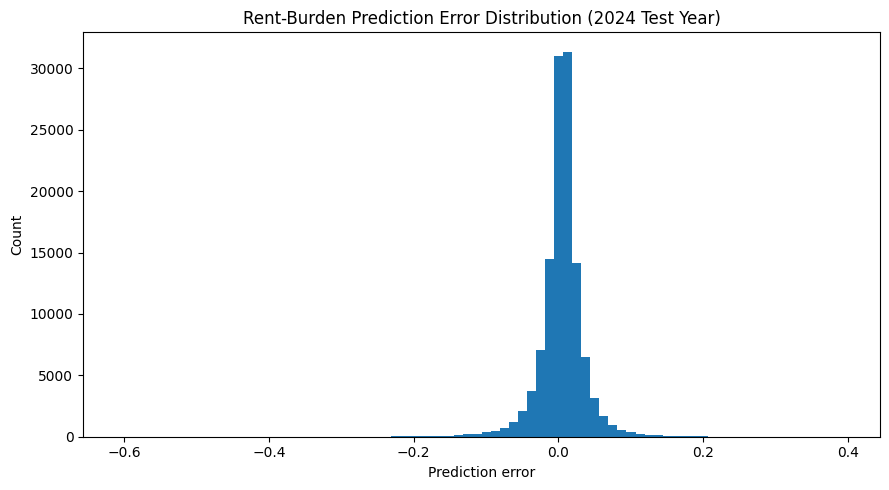

In [32]:
rent_test_predictions = rent_burden_result["test_predictions"]
rent_target_name = rent_burden_result["target_name"]
rent_test_year = rent_burden_result["test_year"]

plt.figure(figsize=(7, 7))
plt.scatter(
    rent_test_predictions[rent_target_name],
    rent_test_predictions["model_prediction"],
    alpha=0.25,
)
plt.plot(
    [
        rent_test_predictions[rent_target_name].min(),
        rent_test_predictions[rent_target_name].max(),
    ],
    [
        rent_test_predictions[rent_target_name].min(),
        rent_test_predictions[rent_target_name].max(),
    ],
    linestyle="--",
)
plt.title(f"Actual vs. Predicted Rent Burden ({rent_test_year} Test Year)")
plt.xlabel("Actual annual rent / annual median wage")
plt.ylabel("Predicted annual rent / annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_actual_vs_predicted_rent_burden_test.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(rent_test_predictions["model_error"], bins=80)
plt.title(f"Rent-Burden Prediction Error Distribution ({rent_test_year} Test Year)")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_rent_burden_residual_distribution.png", dpi=150)
plt.show()

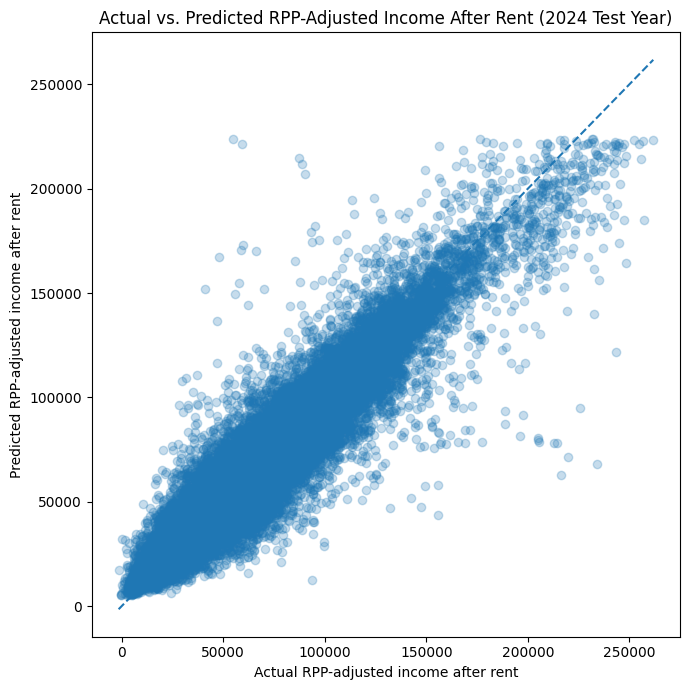

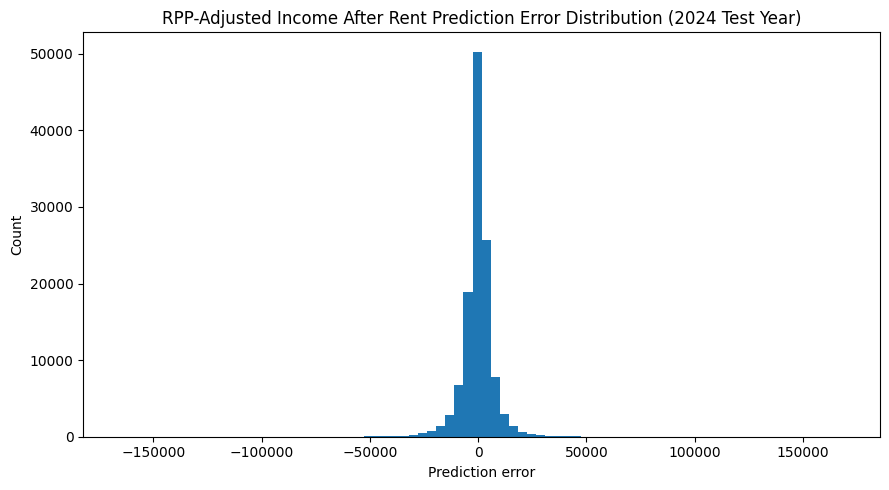

In [33]:
real_test_predictions = real_income_result["test_predictions"]
real_target_name = real_income_result["target_name"]
real_test_year = real_income_result["test_year"]

plt.figure(figsize=(7, 7))
plt.scatter(
    real_test_predictions[real_target_name],
    real_test_predictions["model_prediction"],
    alpha=0.25,
)
plt.plot(
    [
        real_test_predictions[real_target_name].min(),
        real_test_predictions[real_target_name].max(),
    ],
    [
        real_test_predictions[real_target_name].min(),
        real_test_predictions[real_target_name].max(),
    ],
    linestyle="--",
)
plt.title(f"Actual vs. Predicted RPP-Adjusted Income After Rent ({real_test_year} Test Year)")
plt.xlabel("Actual RPP-adjusted income after rent")
plt.ylabel("Predicted RPP-adjusted income after rent")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_actual_vs_predicted_real_income_after_rent_test.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(real_test_predictions["model_error"], bins=80)
plt.title(f"RPP-Adjusted Income After Rent Prediction Error Distribution ({real_test_year} Test Year)")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_real_income_after_rent_residual_distribution.png", dpi=150)
plt.show()

The actual-versus-predicted plots show that both models capture the overall structure of the 2024 test data. Most points follow the diagonal, meaning predictions are generally close to actual values.

The residual histograms are centered near zero, which indicates that the models are not systematically overpredicting or underpredicting for most rows.

However, both targets show some compression at the extremes. Very high or very low values are harder to predict exactly, and the random forest tends to pull extreme predictions closer to the middle. This is common in regression problems with many dense central observations and fewer extreme cases.

For the dashboard, this means the predictions are useful only for directional comparison and short-term ranking.

## 15. Random Forest Feature Importance

Feature importance is computed for the Random Forest model for each target.

This is useful for model explanation, but it should not be interpreted as causal evidence.

Saved feature importance for Rent burden: annual rent / annual median wage: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/random_forest_feature_importance_rent_burden.csv


,target,model,feature,importance
0,Rent burden: annual rent / annual median wage,Tuned Random Forest,rent_to_median_wage_ratio_lag1,0.778048
1,Rent burden: annual rent / annual median wage,Tuned Random Forest,median_wage_to_rent_ratio_lag1,0.208148
2,Rent burden: annual rent / annual median wage,Tuned Random Forest,real_wage_annual_mean_lag1,0.002621
3,Rent burden: annual rent / annual median wage,Tuned Random Forest,cost_adjusted_rent_burden_median_lag1,0.002125
4,Rent burden: annual rent / annual median wage,Tuned Random Forest,annual_rent_lag1,0.001508
5,Rent burden: annual rent / annual median wage,Tuned Random Forest,wage_annual_mean_lag1,0.001441
6,Rent burden: annual rent / annual median wage,Tuned Random Forest,real_wage_annual_median_lag1,0.001124
7,Rent burden: annual rent / annual median wage,Tuned Random Forest,wage_growth_lag1,0.000709
8,Rent burden: annual rent / annual median wage,Tuned Random Forest,wage_annual_median_lag1,0.000563
9,Rent burden: annual rent / annual median wage,Tuned Random Forest,jobs_1000_lag1,0.000514


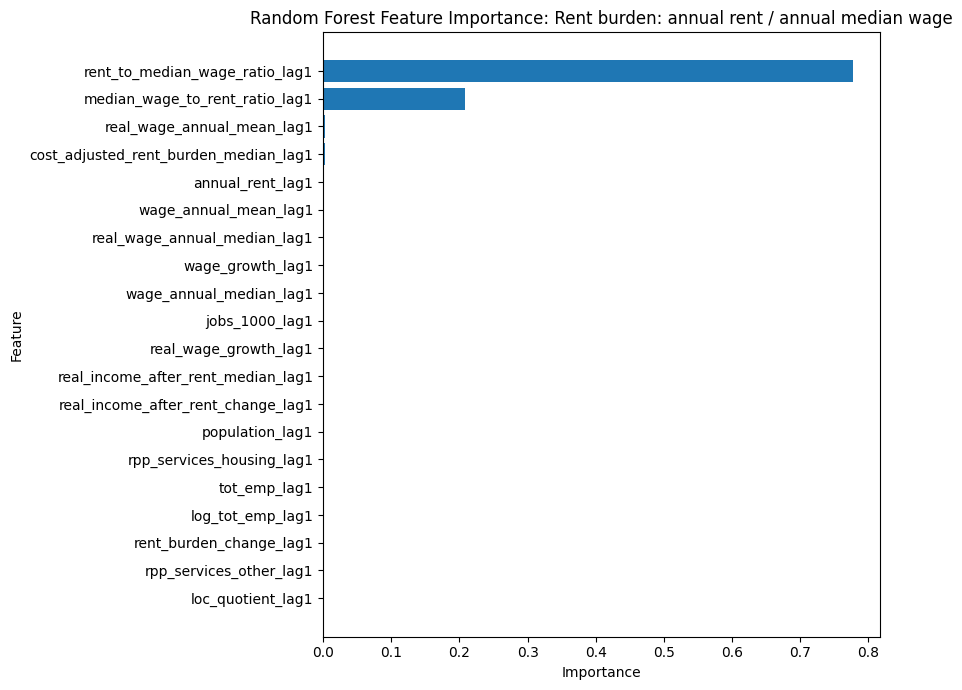

Saved feature importance for RPP-adjusted income after rent: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/random_forest_feature_importance_real_income_after_rent.csv


,target,model,feature,importance
0,RPP-adjusted income after rent,Tuned Random Forest,real_income_after_rent_median_lag1,0.966438
1,RPP-adjusted income after rent,Tuned Random Forest,real_wage_annual_mean_lag1,0.013031
2,RPP-adjusted income after rent,Tuned Random Forest,real_wage_annual_median_lag1,0.006787
3,RPP-adjusted income after rent,Tuned Random Forest,jobs_1000_lag1,0.001076
4,RPP-adjusted income after rent,Tuned Random Forest,wage_annual_mean_lag1,0.001059
5,RPP-adjusted income after rent,Tuned Random Forest,rent_to_median_wage_ratio_lag1,0.000985
6,RPP-adjusted income after rent,Tuned Random Forest,median_wage_to_rent_ratio_lag1,0.000983
7,RPP-adjusted income after rent,Tuned Random Forest,loc_quotient_lag1,0.000786
8,RPP-adjusted income after rent,Tuned Random Forest,wage_annual_median_lag1,0.000608
9,RPP-adjusted income after rent,Tuned Random Forest,rpp_services_other_lag1,0.000540


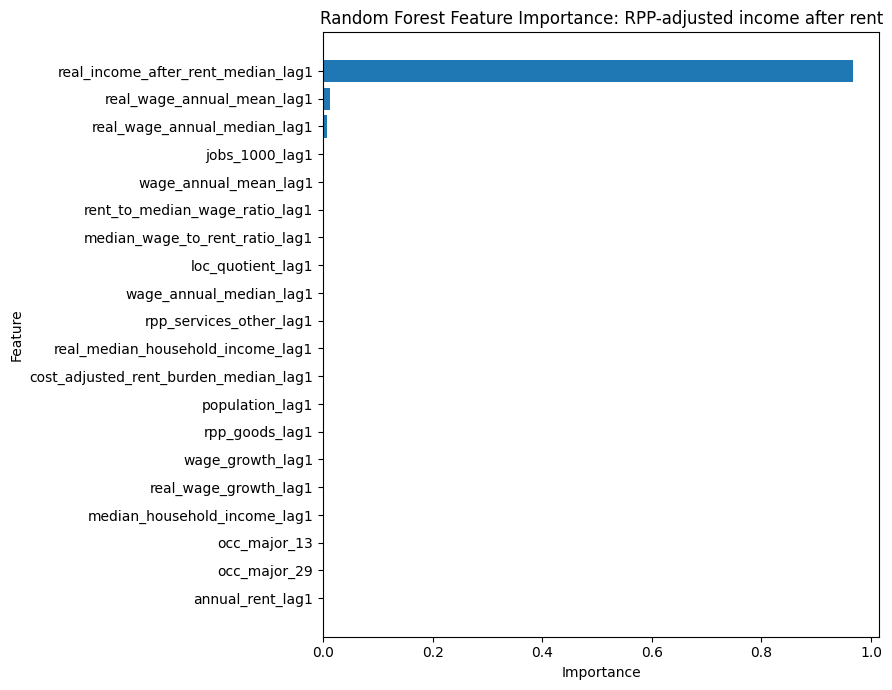

In [34]:
def save_random_forest_importance(result: dict) -> pd.DataFrame | None:
    target_suffix = result["target_suffix"]
    target_label = result["target_label"]

    preferred_rf_model_names = [
        "Tuned Random Forest",
        "Random Forest",
    ]

    rf_pipeline = None
    rf_model_name = None

    for candidate_name in preferred_rf_model_names:
        if candidate_name in result["fitted_models"]:
            rf_pipeline = result["fitted_models"][candidate_name]
            rf_model_name = candidate_name
            break

    if rf_pipeline is None:
        return None

    rf_model = rf_pipeline.named_steps["model"]

    if not hasattr(rf_model, "feature_importances_"):
        return None

    rf_feature_names = get_pipeline_feature_names(
        rf_pipeline,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    rf_importance = (
        pd.DataFrame({
            "target": target_label,
            "model": rf_model_name,
            "feature": rf_feature_names,
            "importance": rf_model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    rf_importance_path = MODELING_DIR / f"random_forest_feature_importance_{target_suffix}.csv"
    rf_importance.to_csv(rf_importance_path, index=False)

    print(f"Saved feature importance for {target_label}: {rf_importance_path}")
    display(rf_importance.head(25))

    top_imp = rf_importance.head(20).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title(f"Random Forest Feature Importance: {target_label}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"06_random_forest_feature_importance_{target_suffix}.png", dpi=150)
    plt.show()

    return rf_importance


rf_importance_rent = save_random_forest_importance(rent_burden_result)
rf_importance_real_income = save_random_forest_importance(real_income_result)

### Feature Importance Analysis

The feature-importance results show that both models rely heavily on lagged versions of the target.

For the rent-burden model, the most important features are:

- `rent_to_median_wage_ratio_lag1`
- `median_wage_to_rent_ratio_lag1`

These are closely related measures of prior-year affordability. This confirms that rent burden is highly persistent.

For the RPP-adjusted income-after-rent model, the dominant feature is:

- `real_income_after_rent_median_lag1`

This means that last year’s cost-adjusted after-rent income is by far the strongest predictor of this year’s value.

These feature-importance results are very common sense, as the previous years' costs and conditions are extremely descriptive of the next years' values.

## 16. Predict Next-Year Outcomes for Latest Available Rows

This creates a dashboard-ready prediction table for the year after the latest observed year.

For example, if the processed dataset ends in 2024, this predicts 2025:

- rent burden
- RPP-adjusted income after rent

In [35]:
future_base = panel.loc[panel["year"] == latest_year].copy()

future_pred = future_base[
    [
        "year",
        "cbsa_code",
        "bls_msa_name",
        "acs_area_name",
        "bea_area_name",
        "prim_state",
        "occ_code",
        "occ_title",
        "wage_annual_median",
        "real_wage_annual_median",
        "annual_rent",
        "rpp_all_items",
        "rpp_services_housing",
        "rent_to_median_wage_ratio",
        "median_wage_to_rent_ratio",
        "cost_adjusted_rent_burden_median",
        "real_income_after_rent_median",
        "tot_emp",
        "jobs_1000",
        "loc_quotient",
        "occ_major",
    ]
].copy()

future_pred["prediction_year"] = latest_year + 1

for col in lag_source_cols:
    if col in future_base.columns:
        future_pred[f"{col}_lag1"] = future_base[col]
        future_pred[f"{col}_lag2"] = future_base.get(f"{col}_lag1")

future_pred["rent_burden_change_lag1"] = (
    future_pred["rent_to_median_wage_ratio_lag1"]
    - future_pred["rent_to_median_wage_ratio_lag2"]
)

future_pred["cost_adjusted_rent_burden_change_lag1"] = (
    future_pred["cost_adjusted_rent_burden_median_lag1"]
    - future_pred["cost_adjusted_rent_burden_median_lag2"]
)

future_pred["real_income_after_rent_change_lag1"] = (
    future_pred["real_income_after_rent_median_lag1"]
    - future_pred["real_income_after_rent_median_lag2"]
)

future_pred["wage_growth_lag1"] = safe_divide(
    future_pred["wage_annual_median_lag1"],
    future_pred["wage_annual_median_lag2"],
) - 1

future_pred["real_wage_growth_lag1"] = safe_divide(
    future_pred["real_wage_annual_median_lag1"],
    future_pred["real_wage_annual_median_lag2"],
) - 1

future_pred["rent_growth_lag1"] = safe_divide(
    future_pred["annual_rent_lag1"],
    future_pred["annual_rent_lag2"],
) - 1

future_pred["employment_growth_lag1"] = safe_divide(
    future_pred["tot_emp_lag1"],
    future_pred["tot_emp_lag2"],
) - 1

future_pred["lq_change_lag1"] = (
    future_pred["loc_quotient_lag1"]
    - future_pred["loc_quotient_lag2"]
)

future_pred["rpp_all_items_change_lag1"] = (
    future_pred["rpp_all_items_lag1"]
    - future_pred["rpp_all_items_lag2"]
)

future_pred["rpp_housing_change_lag1"] = (
    future_pred["rpp_services_housing_lag1"]
    - future_pred["rpp_services_housing_lag2"]
)

future_pred = future_pred.replace([np.inf, -np.inf], np.nan)

future_model_input = future_pred[feature_cols]

future_pred["predicted_next_year_rent_to_median_wage_ratio"] = np.maximum(
    rent_burden_result["final_model"].predict(future_model_input),
    0.000001,
)

future_pred["predicted_next_year_median_wage_to_rent_ratio"] = safe_divide(
    pd.Series(1.0, index=future_pred.index),
    future_pred["predicted_next_year_rent_to_median_wage_ratio"],
)

future_pred["predicted_change_in_rent_burden"] = (
    future_pred["predicted_next_year_rent_to_median_wage_ratio"]
    - future_pred["rent_to_median_wage_ratio"]
)

future_pred["predicted_improving_rent_burden"] = (
    future_pred["predicted_change_in_rent_burden"] < 0
)

future_pred["predicted_next_year_real_income_after_rent_median"] = (
    real_income_result["final_model"].predict(future_model_input)
)

future_pred["predicted_change_in_real_income_after_rent"] = (
    future_pred["predicted_next_year_real_income_after_rent_median"]
    - future_pred["real_income_after_rent_median"]
)

future_pred["predicted_improving_real_income_after_rent"] = (
    future_pred["predicted_change_in_real_income_after_rent"] > 0
)

future_output_cols = [
    "prediction_year",
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "bea_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "wage_annual_median",
    "real_wage_annual_median",
    "annual_rent",
    "rpp_all_items",
    "rpp_services_housing",
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "cost_adjusted_rent_burden_median",
    "real_income_after_rent_median",
    "tot_emp",
    "jobs_1000",
    "loc_quotient",
    "predicted_next_year_rent_to_median_wage_ratio",
    "predicted_next_year_median_wage_to_rent_ratio",
    "predicted_change_in_rent_burden",
    "predicted_improving_rent_burden",
    "predicted_next_year_real_income_after_rent_median",
    "predicted_change_in_real_income_after_rent",
    "predicted_improving_real_income_after_rent",
]

future_pred[future_output_cols].to_csv(FUTURE_PREDICTIONS_CSV_PATH, index=False)

print_shape("Next-year prediction table", future_pred[future_output_cols])
print(f"Saved: {FUTURE_PREDICTIONS_CSV_PATH}")

display(
    future_pred[future_output_cols]
    .sort_values("predicted_change_in_real_income_after_rent", ascending=False)
    .head(15)
)

Next-year prediction table: 141,164 rows × 28 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/career_city_next_year_predictions_latest.csv


,prediction_year,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,wage_annual_median,...,tot_emp,jobs_1000,loc_quotient,predicted_next_year_rent_to_median_wage_ratio,predicted_next_year_median_wage_to_rent_ratio,predicted_change_in_rent_burden,predicted_improving_rent_burden,predicted_next_year_real_income_after_rent_median,predicted_change_in_real_income_after_rent,predicted_improving_real_income_after_rent
356219,2025,2024,31420,"Macon-Bibb County, GA","Macon-Bibb County, GA Metro Area","Macon-Bibb County, GA (Metropolitan Statistica...",GA,29-1229,"Physicians, All Other",58290.0,...,190.0,2.005,0.98,0.217615,4.595273,0.002690,False,82503.381276,30811.261268,True
400540,2025,2024,34740,"Muskegon-Norton Shores, MI","Muskegon-Norton Shores, MI Metro Area","Muskegon-Norton Shores, MI (Metropolitan Stati...",MI,29-1229,"Physicians, All Other",62940.0,...,70.0,1.182,0.58,0.197977,5.051086,0.001981,False,84897.189745,30201.397529,True
435356,2025,2024,36740,"Orlando-Kissimmee-Sanford, FL","Orlando-Kissimmee-Sanford, FL Metro Area","Orlando-Kissimmee-Sanford, FL (Metropolitan St...",FL,29-1215,Family Medicine Physicians,150230.0,...,1680.0,1.199,1.71,0.147185,6.794183,0.006600,False,157257.852600,29953.034915,True
311418,2025,2024,29180,"Lafayette, LA","Lafayette, LA Metro Area","Lafayette, LA (Metropolitan Statistical Area)",LA,11-1011,Chief Executives,123560.0,...,50.0,0.288,0.21,0.099127,10.088105,0.004242,False,157970.036183,29730.978288,True
634912,2025,2024,48060,"Watertown-Fort Drum, NY","Watertown-Fort Drum, NY Metro Area","Watertown-Fort Drum, NY (Metropolitan Statisti...",NY,11-2021,Marketing Managers,127970.0,...,30.0,0.837,0.34,0.119348,8.378838,0.005603,False,158944.305441,29609.147498,True
32665,2025,2024,12060,"Atlanta-Sandy Springs-Roswell, GA","Atlanta-Sandy Springs-Roswell, GA Metro Area","Atlanta-Sandy Springs-Roswell, GA (Metropolita...",GA,27-2021,Athletes and Sports Competitors,72240.0,...,1860.0,0.647,6.94,0.290136,3.446655,0.012395,False,81710.134599,29564.379137,True
491457,2025,2024,40140,"Riverside-San Bernardino-Ontario, CA","Riverside-San Bernardino-Ontario, CA Metro Area","Riverside-San Bernardino-Ontario, CA (Metropol...",CA,29-1229,"Physicians, All Other",80550.0,...,1890.0,1.112,0.54,0.280094,3.570229,0.005085,False,84109.138894,29245.457264,True
537242,2025,2024,41940,"San Jose-Sunnyvale-Santa Clara, CA","San Jose-Sunnyvale-Santa Clara, CA Metro Area","San Jose-Sunnyvale-Santa Clara, CA (Metropolit...",CA,29-1229,"Physicians, All Other",95320.0,...,2460.0,2.171,1.06,0.360568,2.773400,0.003036,False,84122.742489,28663.282051,True
562106,2025,2024,43340,"Shreveport-Bossier City, LA","Shreveport-Bossier City, LA Metro Area","Shreveport-Bossier City, LA (Metropolitan Stat...",LA,11-1031,Legislators,16430.0,...,40.0,0.261,1.52,0.577052,1.732945,-0.163544,True,33642.835480,28614.876157,True
582694,2025,2024,44700,"Stockton-Lodi, CA","Stockton-Lodi, CA Metro Area","Stockton-Lodi, CA (Metropolitan Statistical Area)",CA,29-1229,"Physicians, All Other",79420.0,...,370.0,1.293,0.63,0.254433,3.930313,-0.007567,True,84274.567689,28500.890140,True


### Next-year Prediction Outputs

The next-year prediction table contains **141,164 rows** and creates forecasted values for the year after the latest observed year. Since the latest observed year is 2024, these predictions represent 2025 signals.

The table includes predicted next-year rent burden, predicted next-year wage-to-rent ratio, predicted change in rent burden, predicted next-year RPP-adjusted income after rent, and predicted change in RPP-adjusted income after rent.

This output is designed for the dashboard. It lets the dashboard show not only where a metro stands now, but also whether the model expects the career-city pair to improve or worsen in the near term.

These are only informational as short-term model signals.

## 17. Combined Dashboard Modeling Output

This combines:

- latest-year RPP-aware ranking score
- metro cluster labels and PCA coordinates
- next-year rent-burden predictions
- next-year RPP-adjusted income-after-rent predictions

The dashboard can read this one file directly for filtering, ranking, and visualization.

In [36]:
dashboard_output = score_df.merge(
    metro_profile[
        [
            "cbsa_code",
            "metro_cluster",
            "pca_1",
            "pca_2",
            "rpp_all_items",
            "rpp_services_housing",
            "mean_rent_burden",
            "mean_cost_adjusted_rent_burden",
            "mean_occ_wage",
            "mean_real_occ_wage",
            "mean_real_income_after_rent",
            "share_high_lq",
        ]
    ],
    on="cbsa_code",
    how="left",
    suffixes=("", "_metro"),
)

dashboard_output = dashboard_output.merge(
    future_pred[
        [
            "cbsa_code",
            "occ_code",
            "prediction_year",
            "predicted_next_year_rent_to_median_wage_ratio",
            "predicted_next_year_median_wage_to_rent_ratio",
            "predicted_change_in_rent_burden",
            "predicted_improving_rent_burden",
            "predicted_next_year_real_income_after_rent_median",
            "predicted_change_in_real_income_after_rent",
            "predicted_improving_real_income_after_rent",
        ]
    ],
    on=["cbsa_code", "occ_code"],
    how="left",
)

dashboard_output.to_csv(FINAL_DASHBOARD_OUTPUT_CSV_PATH, index=False)

print_shape("Combined dashboard modeling output", dashboard_output)
print(f"Saved: {FINAL_DASHBOARD_OUTPUT_CSV_PATH}")

display(dashboard_output.head(15))

Combined dashboard modeling output: 137,464 rows × 51 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/dashboard_modeling_output_latest.csv


,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,wage_annual_median,real_wage_annual_median,...,mean_real_income_after_rent,share_high_lq,prediction_year,predicted_next_year_rent_to_median_wage_ratio,predicted_next_year_median_wage_to_rent_ratio,predicted_change_in_rent_burden,predicted_improving_rent_burden,predicted_next_year_real_income_after_rent_median,predicted_change_in_real_income_after_rent,predicted_improving_real_income_after_rent
0,2024,44100,"Springfield, IL","Springfield, IL Metro Area","Springfield, IL (Metropolitan Statistical Area)",IL,13-2011,Accountants and Auditors,83970.0,90538.573508,...,54158.762334,0.309148,2025,0.156918,6.372765,0.017011,False,79070.044781,1198.461407,True
1,2024,37620,"Parkersburg-Vienna, WV","Parkersburg-Vienna, WV Metro Area","Parkersburg-Vienna, WV (Metropolitan Statistic...",WV,13-2011,Accountants and Auditors,95640.0,109847.701744,...,51097.071728,0.434524,2025,0.117479,8.512147,0.014844,False,97405.620535,-1167.875434,False
2,2024,43620,"Sioux Falls, SD-MN","Sioux Falls, SD-MN Metro Area","Sioux Falls, SD-MN (Metropolitan Statistical A...",SD,13-2011,Accountants and Auditors,79650.0,87883.836656,...,52261.957857,0.41519,2025,0.162511,6.153435,0.008537,False,77668.804736,3316.761837,True
3,2024,33220,"Midland, MI","Midland, MI Metro Area","Midland, MI (Metropolitan Statistical Area)",MI,13-2011,Accountants and Auditors,86390.0,93982.876601,...,58936.010017,0.369318,2025,0.147781,6.766784,0.006653,False,82818.869858,2099.556535,True
4,2024,19340,"Davenport-Moline-Rock Island, IA-IL","Davenport-Moline-Rock Island, IA-IL Metro Area","Davenport-Moline-Rock Island, IA-IL (Metropoli...",IA,13-2011,Accountants and Auditors,77280.0,86754.453912,...,55706.311055,0.262181,2025,0.151661,6.593641,0.005543,False,76782.551970,2704.486433,True
5,2024,46140,"Tulsa, OK","Tulsa, OK Metro Area","Tulsa, OK (Metropolitan Statistical Area)",OK,13-2011,Accountants and Auditors,78500.0,87990.674109,...,51285.402774,0.277014,2025,0.173289,5.770716,0.008499,False,76435.236737,2944.529001,True
6,2024,48620,"Wichita, KS","Wichita, KS Metro Area","Wichita, KS (Metropolitan Statistical Area)",KS,13-2011,Accountants and Auditors,74890.0,84197.153329,...,53080.868529,0.274678,2025,0.166150,6.018658,0.007998,False,72798.320331,1917.111508,True
7,2024,15380,"Buffalo-Cheektowaga, NY","Buffalo-Cheektowaga, NY Metro Area","Buffalo-Cheektowaga, NY (Metropolitan Statisti...",NY,13-2011,Accountants and Auditors,80240.0,83719.377321,...,58561.890821,0.280277,2025,0.168368,5.939384,0.010292,False,73640.381643,3155.009580,True
8,2024,11180,"Ames, IA","Ames, IA Metro Area","Ames, IA (Metropolitan Statistical Area)",IA,13-2011,Accountants and Auditors,76250.0,85838.117753,...,57220.020332,0.375479,2025,0.165720,6.034269,0.008343,False,70550.517871,-1778.650203,False
9,2024,17410,"Cleveland, OH","Cleveland, OH Metro Area","Cleveland, OH (Metropolitan Statistical Area)",OH,13-2011,Accountants and Auditors,78360.0,83430.043759,...,53839.778712,0.25938,2025,0.169851,5.887505,0.009055,False,72803.218895,2788.419538,True


### Combined dashboard output interpretation

The combined dashboard modeling output contains **137,464 rows and 51 columns**. This file combines the latest-year dashboard score, cluster labels, PCA coordinates, metro-level profile metrics, nearest-year prediction values, and improvement flags.

This is the main final data product for the dashboard. It allows the dashboard to support several user-facing views:

- occupation-specific metro rankings,
- rent burden and after-rent income comparisons,
- predicted next-year improvement,
- cluster-based metro grouping,
- similar-metro recommendations,
- and detailed metric breakdowns for each career-city pair.

The important design choice is that the dashboard gives users a balanced score while also preserving the underlying variables so they can understand the tradeoffs.

## 18. SQL-Based Dashboard Verification Queries

This section uses SQL to verify the final dashboard modeling tables.

These queries demonstrate how the exported dashboard data can support:

1. occupation-specific rankings,
2. cluster-level summaries,
3. nearest-neighbor metro recommendations.

In [37]:
import duckdb

dashboard_sql_con = duckdb.connect(database=":memory:")

dashboard_sql_con.register("dashboard_output", dashboard_output)
dashboard_sql_con.register("nearest_metros", nearest_metros)
dashboard_sql_con.register("metro_profile", metro_profile)

selected_occ_for_sql = example_occupation if "example_occupation" in globals() else (
    dashboard_output["occ_title"].dropna().value_counts().index[0]
)

selected_metro_for_sql = example_source_metro if "example_source_metro" in globals() else (
    dashboard_output["bls_msa_name"].dropna().value_counts().index[0]
)

print(f"Selected occupation for dashboard SQL: {selected_occ_for_sql}")
print(f"Selected metro for nearest-neighbor SQL: {selected_metro_for_sql}")

sql_top_dashboard = dashboard_sql_con.execute(
    """
    SELECT
        bls_msa_name,
        occ_title,
        career_city_score_0_100,
        wage_annual_median,
        real_wage_annual_median,
        annual_rent,
        rpp_all_items,
        real_income_after_rent_median,
        rent_to_median_wage_ratio,
        tot_emp,
        loc_quotient,
        predicted_change_in_real_income_after_rent,
        predicted_improving_real_income_after_rent
    FROM dashboard_output
    WHERE occ_title = ?
      AND COALESCE(tot_emp, 0) >= 100
    ORDER BY career_city_score_0_100 DESC
    LIMIT 15
    """,
    [selected_occ_for_sql],
).df()

print("Top dashboard-ranked metros for selected occupation:")
display(sql_top_dashboard)

sql_cluster_summary = dashboard_sql_con.execute(
    """
    SELECT
        metro_cluster,
        COUNT(DISTINCT cbsa_code) AS n_metros,
        ROUND(AVG(rpp_all_items), 2) AS avg_rpp_all_items,
        ROUND(AVG(annual_rent), 0) AS avg_annual_rent,
        ROUND(AVG(real_income_after_rent_median), 0) AS avg_real_income_after_rent,
        ROUND(AVG(career_city_score_0_100), 2) AS avg_career_city_score
    FROM dashboard_output
    GROUP BY metro_cluster
    ORDER BY metro_cluster
    """
).df()

print("Cluster-level dashboard summary:")
display(sql_cluster_summary)

sql_nearest = dashboard_sql_con.execute(
    """
    SELECT
        source_metro,
        neighbor_rank,
        neighbor_metro,
        neighbor_cluster,
        distance,
        neighbor_annual_rent,
        neighbor_rpp_all_items,
        neighbor_mean_real_income_after_rent,
        neighbor_share_high_lq
    FROM nearest_metros
    WHERE source_metro = ?
    ORDER BY neighbor_rank
    LIMIT 10
    """,
    [selected_metro_for_sql],
).df()

print("Nearest-neighbor metros:")
display(sql_nearest)

dashboard_sql_con.close()

Selected occupation for dashboard SQL: Software Developers
Selected metro for nearest-neighbor SQL: New York-Newark-Jersey City, NY-NJ
Top dashboard-ranked metros for selected occupation:


,bls_msa_name,occ_title,career_city_score_0_100,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,real_income_after_rent_median,rent_to_median_wage_ratio,tot_emp,loc_quotient,predicted_change_in_real_income_after_rent,predicted_improving_real_income_after_rent
0,"Binghamton, NY",Software Developers,94.523810,129600.0,139560.427727,11268,92.863,127426.423872,0.086944,1130.0,1.10,-3002.930489,False
1,"Ames, IA",Software Developers,91.316138,127040.0,143014.747270,12000,88.830,129505.797591,0.094458,440.0,0.73,-7332.590929,False
2,"Buffalo-Cheektowaga, NY",Software Developers,91.183862,128780.0,134364.175118,12684,95.844,121130.169859,0.098494,3720.0,0.65,-2436.877654,False
3,"Des Moines-West Des Moines, IA",Software Developers,90.251323,124630.0,135909.095866,13800,91.701,120860.186912,0.110728,4750.0,1.09,-1209.617275,False
4,"Bloomington, IL",Software Developers,89.179894,121590.0,129991.340325,12108,93.537,117046.730171,0.099581,1300.0,1.35,-2967.798109,False
5,"Winston-Salem, NC",Software Developers,88.544974,125140.0,135958.193453,12192,92.043,122712.210597,0.097427,1270.0,0.43,2276.862966,True
6,"Rochester, MN",Software Developers,87.949735,130480.0,143667.213530,15312,90.821,126807.676639,0.117351,1630.0,1.25,4700.918785,True
7,"Pittsburgh, PA",Software Developers,87.202381,122350.0,129237.041966,12636,94.671,115889.765609,0.103277,8820.0,0.74,-1618.155694,False
8,"Pittsfield, MA",Software Developers,86.686508,132760.0,139591.613568,13164,95.106,125750.215549,0.099156,310.0,0.51,-1031.330362,False
9,"El Paso, TX",Software Developers,84.695767,121160.0,134753.981671,12948,89.912,120353.234274,0.106867,1300.0,0.36,-1869.881165,False


Cluster-level dashboard summary:


,metro_cluster,n_metros,avg_rpp_all_items,avg_annual_rent,avg_real_income_after_rent,avg_career_city_score
0,1,52,104.66,21342.0,48418.0,44.02
1,2,114,89.41,12006.0,48846.0,52.60
2,3,55,98.73,17801.0,42321.0,34.05
3,4,126,92.75,13088.0,52285.0,58.35
4,5,40,101.59,16805.0,50817.0,52.91


Nearest-neighbor metros:


,source_metro,neighbor_rank,neighbor_metro,neighbor_cluster,distance,neighbor_annual_rent,neighbor_rpp_all_items,neighbor_mean_real_income_after_rent,neighbor_share_high_lq
0,"New York-Newark-Jersey City, NY-NJ",1,"Los Angeles-Long Beach-Anaheim, CA",1,5.463845,24756.0,113.566,45109.639862,0.267882
1,"New York-Newark-Jersey City, NY-NJ",2,"Sacramento-Roseville-Folsom, CA",1,5.764098,21828.0,106.670,51821.199453,0.252322
2,"New York-Newark-Jersey City, NY-NJ",3,"Seattle-Tacoma-Bellevue, WA",1,6.365317,24000.0,111.133,51608.697087,0.272861
3,"New York-Newark-Jersey City, NY-NJ",4,"Minneapolis-St. Paul-Bloomington, MN-WI",1,6.411509,17280.0,104.822,53129.007350,0.199695
4,"New York-Newark-Jersey City, NY-NJ",5,"Chicago-Naperville-Elgin, IL-IN",1,6.511859,17160.0,103.595,50891.980534,0.192475
5,"New York-Newark-Jersey City, NY-NJ",6,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",1,6.756844,17760.0,102.554,49649.857486,0.202201
6,"New York-Newark-Jersey City, NY-NJ",7,"Baltimore-Columbia-Towson, MD",1,6.812585,19332.0,104.487,48806.968134,0.306709
7,"New York-Newark-Jersey City, NY-NJ",8,"Portland-Vancouver-Hillsboro, OR-WA",1,6.943213,20688.0,105.421,49945.326892,0.306306
8,"New York-Newark-Jersey City, NY-NJ",9,"Boston-Cambridge-Newton, MA-NH",1,7.248002,24276.0,108.266,48785.976978,0.292868
9,"New York-Newark-Jersey City, NY-NJ",10,"Denver-Aurora-Centennial, CO",1,7.711753,22488.0,105.782,47456.564868,0.282714


### Dashboard SQL Verification

The SQL verification queries confirm that the final dashboard data can answer the main product questions.

For software developers, the top dashboard-ranked metros include Binghamton, Ames, Buffalo, Des Moines, Bloomington, Winston-Salem, Rochester, Pittsburgh, Pittsfield, and El Paso. These are balanced metros that score well across affordability, adjusted income, rent burden, and labor-market measures.

The cluster summary shows that Cluster 4 has the strongest average dashboard score, while Cluster 1 contains more expensive large metros. This supports the idea that different metro clusters represent different tradeoffs.

The nearest-neighbor query shows that a user can start with one familiar metro, such as New York, and compare it with similar metros like Los Angeles, Seattle, Chicago, Philadelphia, Boston, Denver, and others.

Together, these queries show that the final output is dashboard-ready.

## 19. Final Artifact Summary

In [38]:
artifact_summary = pd.DataFrame(
    [
        {
            "artifact": "latest occupation-metro RPP-aware dashboard score",
            "path": str(LATEST_SCORE_CSV_PATH),
        },
        {
            "artifact": "clustered metro profiles",
            "path": str(METRO_PROFILE_CSV_PATH),
        },
        {
            "artifact": "nearest-neighbor metro table",
            "path": str(NEAREST_METROS_CSV_PATH),
        },
        {
            "artifact": "combined regression metrics",
            "path": str(REGRESSION_METRICS_ALL_TARGETS_CSV_PATH),
        },
        {
            "artifact": "rent-burden model metrics",
            "path": str(rent_burden_result["metrics_path"]),
        },
        {
            "artifact": "real-income-after-rent model metrics",
            "path": str(real_income_result["metrics_path"]),
        },
        {
            "artifact": "next-year predictions",
            "path": str(FUTURE_PREDICTIONS_CSV_PATH),
        },
        {
            "artifact": "combined dashboard modeling output",
            "path": str(FINAL_DASHBOARD_OUTPUT_CSV_PATH),
        },
        {
            "artifact": "model directory",
            "path": str(MODEL_DIR),
        },
        {
            "artifact": "modeling figures directory",
            "path": str(FIG_DIR),
        },
    ]
)

display(artifact_summary)

,artifact,path
0,latest occupation-metro RPP-aware dashboard score,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
1,clustered metro profiles,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
2,nearest-neighbor metro table,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
3,combined regression metrics,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
4,rent-burden model metrics,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
5,real-income-after-rent model metrics,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
6,next-year predictions,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
7,combined dashboard modeling output,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
8,model directory,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
9,modeling figures directory,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...


The modeling notebook exports several dashboard and modeling artifacts:

- latest-year dashboard scores,
- clustered metro profiles,
- nearest-neighbor metro recommendations,
- regression model metrics,
- test prediction files,
- feature-importance files,
- next-year prediction tables,
- and the final combined dashboard modeling output.

This allows the interactive dashboard to load prepared files rather than require the full wrangling and modeling pipeline each time.

This is important for usability and reproducibility. The notebook documents how each artifact was created, while the exported files make the final product easier to demo.

## Main Takeaways

This notebook turns the cleaned occupation-metro dataset into dashboard-ready rankings, metro clusters, similar-metro recommendations, and short-term forecasts.

The dashboard score provides a transparent way to rank metros within each occupation. It balances RPP-adjusted income after rent, rent affordability, real wages, location quotient, and employment scale. This prevents the dashboard from relying only on nominal wage or only on rent.

The clustering section groups metros into broad market types. The clusters are exploratory rather than definitive, but they help summarize differences between large expensive metros, lower-cost metros, specialized midsize metros, and more balanced affordability-oriented markets.

The nearest-neighbor table allows users to ask not only “what is the best metro?”, but also “what metros are similar to this one?” and compare alternatives.

The supervised modeling results show that career-city affordability is highly persistent over time. For rent burden, the persistence baseline is very strong and slightly better on MAE, while the tuned random forest improves RMSE and R². For RPP-adjusted income after rent, the tuned random forest performs best overall and beats the persistence baseline on the 2024 test set.

The feature-importance results confirm that lagged affordability variables dominate the forecasts. This means the models are best understood as short-term forecasting tools.

The final dashboard output combines current scores, metro clusters, PCA coordinates, and next-year predictions into one file. This supports a dashboard that can help users compare career-city options by affordability, cost-adjusted purchasing power, labor-market depth, and predicted near-term direction.